# CaLiCo-Lens Prototype: Stage-A Single Seed + Stage-B Verifier

This notebook runs:

1. **Stage A**: a **single-seed** DensePolarNet-Robust baseline (seed 42) to produce candidate scores and a reusable checkpoint.
2. **Stage B**: **CaLiCo-Lens**, a prototype **Contaminant-Aware Lens-Consistency verifier** built on top of the frozen Stage-A encoder.

The goal of this notebook is **viability checking**, not claiming final superiority over the best 3-seed ensemble.  
It is designed to test whether explicit **contaminant modeling**, **geometry-guided canonicalization**, and **annular relation reasoning** can improve low-FPR behavior and give a stronger research direction for observational strong-lens finding.

**Important**
- This is a **research prototype**.
- The main benchmark to beat remains the best previous result (the 3-seed ensemble).
- If Stage B underperforms, that is still scientifically useful because it reveals which added assumptions are helping or hurting.


In [1]:
# # OPTIONAL: run only in a fresh Kaggle session if PyTorch does not support the P100.
# !pip uninstall -y -q torch torchvision torchaudio
# !pip install -q --no-cache-dir --force-reinstall \
#     torch==2.4.1 torchvision==0.19.1 torchaudio==2.4.1 \
#     --index-url https://download.pytorch.org/whl/cu118


In [2]:
import torch, torchvision

print("torch:", torch.__version__)
print("torch cuda:", torch.version.cuda)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("arch list:", torch.cuda.get_arch_list())

use_cuda = torch.cuda.is_available() and ("sm_60" in torch.cuda.get_arch_list())
device = torch.device("cuda" if use_cuda else "cpu")
print("Using device:", device)


torch: 2.4.1+cu118
torch cuda: 11.8
cuda available: True
gpu: Tesla P100-PCIE-16GB
arch list: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_37', 'sm_90']
Using device: cuda


In [3]:
import os
import gc
import math
import time
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, matthews_corrcoef,
    cohen_kappa_score, brier_score_loss, precision_recall_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision.models import (
    densenet121, densenet161,
    DenseNet121_Weights, DenseNet161_Weights
)

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)


In [4]:
class CFG:
    # model
    MODEL_NAME = "densenet161"
    PRETRAINED = False
    SMALL_IMAGE_STEM = True
    USE_POLAR_BRANCH = True
    USE_RADIAL_BRANCH = True
    MEMORY_EFFICIENT = True

    # split / ensemble
    SPLIT_SEED = 42
    ENSEMBLE_SEEDS = [42]

    # data
    IMG_SIZE = 64
    VALID_SIZE = 0.10
    NUM_WORKERS = 2

    # augmentation
    P_FLIP = 0.5
    MAX_SHIFT = 3
    P_BAND_DROPOUT = 0.20
    P_NOISE = 0.30
    NOISE_STD_MAX = 0.03
    P_GAIN_JITTER = 0.50
    GAIN_JITTER = 0.12

    # training
    EPOCHS = 18
    BATCH_SIZE = 20
    LR = 2e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 5
    AMP = True
    CLIP_GRAD_NORM = 1.0

    # imbalance
    FOCAL_ALPHA = 0.80
    FOCAL_GAMMA = 2.0

    # EMA
    USE_EMA = True
    EMA_DECAY = 0.999

    # inference
    USE_TTA = True
    TTA_D4 = True

    # threshold search on validation
    THRESH_GRID = np.linspace(0.05, 0.95, 181)

    # outputs
    SAVE_DIR = Path("/kaggle/working/densepolar_seed42_baseline")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

CFG.__dict__


mappingproxy({'__module__': '__main__',
              'MODEL_NAME': 'densenet161',
              'PRETRAINED': False,
              'SMALL_IMAGE_STEM': True,
              'USE_POLAR_BRANCH': True,
              'USE_RADIAL_BRANCH': True,
              'MEMORY_EFFICIENT': True,
              'SPLIT_SEED': 42,
              'ENSEMBLE_SEEDS': [42],
              'IMG_SIZE': 64,
              'VALID_SIZE': 0.1,
              'NUM_WORKERS': 2,
              'P_FLIP': 0.5,
              'MAX_SHIFT': 3,
              'P_BAND_DROPOUT': 0.2,
              'P_NOISE': 0.3,
              'NOISE_STD_MAX': 0.03,
              'P_GAIN_JITTER': 0.5,
              'GAIN_JITTER': 0.12,
              'EPOCHS': 18,
              'BATCH_SIZE': 20,
              'LR': 0.0002,
              'WEIGHT_DECAY': 0.0001,
              'PATIENCE': 5,
              'AMP': True,
              'CLIP_GRAD_NORM': 1.0,
              'FOCAL_ALPHA': 0.8,
              'FOCAL_GAMMA': 2.0,
              'USE_EMA': True,
    

In [5]:
# =========================
# HF / Stage-A checkpoint setup
# =========================
# !pip -q install -U huggingface_hub

from pathlib import Path
from kaggle_secrets import UserSecretsClient
from huggingface_hub import hf_hub_download

user_secrets = UserSecretsClient()

HF_STAGE_A_REPO = user_secrets.get_secret("HF_REPO")
HF_STAGE_A_TOKEN = user_secrets.get_secret("HF_TOKEN")
HF_STAGE_A_REPO_TYPE = "dataset"
HF_STAGE_A_FILENAME_TEMPLATE = "best_densepolar_robust_seed_{seed}.pt"

USE_HF_STAGE_A = True
FORCE_STAGE_A_RETRAIN = False

print("HF_STAGE_A_REPO:", HF_STAGE_A_REPO)
print("CFG.SAVE_DIR:", CFG.SAVE_DIR)

HF_STAGE_A_REPO: Arushhh/deeplense-test5-densepolar-artifacts
CFG.SAVE_DIR: /kaggle/working/densepolar_seed42_baseline


In [6]:
def find_dataset_root():
    needed = ["train_lenses", "train_nonlenses", "test_lenses", "test_nonlenses"]

    explicit_candidates = [
        Path("/kaggle/input/datasets/arushhh/dataset-task-v"),
        Path("/kaggle/input/datasets/aryanaru69/dataset-task-v"),
    ]
    for root in explicit_candidates:
        if root.exists() and all((root / x).exists() for x in needed):
            return root

    for p in Path("/kaggle/input").rglob("*"):
        if p.is_dir() and all((p / x).exists() for x in needed):
            return p

    raise FileNotFoundError("Could not find dataset root under /kaggle/input.")

CFG.ROOT = find_dataset_root()
print("Using dataset root:", CFG.ROOT)


Using dataset root: /kaggle/input/datasets/aryanaru69/dataset-task-v


In [7]:
def build_dataframe(root):
    rows = []
    mapping = {
        "train_lenses": (1, "train"),
        "train_nonlenses": (0, "train"),
        "test_lenses": (1, "test"),
        "test_nonlenses": (0, "test"),
    }

    for folder, (label, split) in mapping.items():
        folder_path = Path(root) / folder
        files = sorted(folder_path.glob("*.npy"))
        rows.extend([{
            "path": str(f),
            "label": label,
            "split": split,
            "folder": folder
        } for f in files])

    return pd.DataFrame(rows)

df = build_dataframe(CFG.ROOT)
print(df["folder"].value_counts())
display(df.head())

train_df = df[df["split"] == "train"].reset_index(drop=True).copy()
test_df  = df[df["split"] == "test"].reset_index(drop=True).copy()

train_idx, valid_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=CFG.VALID_SIZE,
    stratify=train_df["label"].values,
    random_state=CFG.SPLIT_SEED
)

trn_df = train_df.iloc[train_idx].reset_index(drop=True)
val_df = train_df.iloc[valid_idx].reset_index(drop=True)

print("Train split size:", len(trn_df), " | lens fraction:", trn_df["label"].mean())
print("Valid split size:", len(val_df), " | lens fraction:", val_df["label"].mean())
print("Held-out test size:", len(test_df), " | lens fraction:", test_df["label"].mean())


folder
train_nonlenses    28675
test_nonlenses     19455
train_lenses        1730
test_lenses          195
Name: count, dtype: int64


,path,label,split,folder
0,/kaggle/input/datasets/aryanaru69/dataset-task...,1,train,train_lenses
1,/kaggle/input/datasets/aryanaru69/dataset-task...,1,train,train_lenses
2,/kaggle/input/datasets/aryanaru69/dataset-task...,1,train,train_lenses
3,/kaggle/input/datasets/aryanaru69/dataset-task...,1,train,train_lenses
4,/kaggle/input/datasets/aryanaru69/dataset-task...,1,train,train_lenses


Train split size: 27364  | lens fraction: 0.05689957608536764
Valid split size: 3041  | lens fraction: 0.056889181190397896
Held-out test size: 19650  | lens fraction: 0.009923664122137405


torch.Size([3, 64, 64]) torch.float32 tensor(0.)


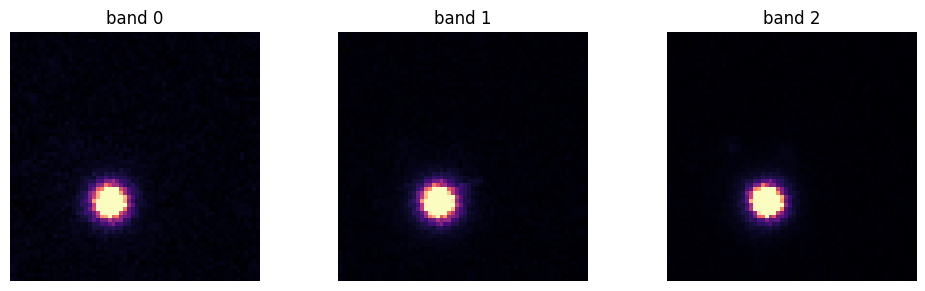

In [8]:
def load_npy(path):
    x = np.load(path)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    if x.ndim != 3:
        raise ValueError(f"Expected 3D array, got shape {x.shape} for {path}")

    if x.shape[0] == 3:
        pass
    elif x.shape[-1] == 3:
        x = np.transpose(x, (2, 0, 1))
    else:
        raise ValueError(f"Expected channel dimension of 3, got shape {x.shape} for {path}")

    return x

def astrophysical_stretch(x):
    x = np.maximum(x, 0.0)
    out = np.zeros_like(x, dtype=np.float32)

    for c in range(x.shape[0]):
        scale = np.percentile(x[c], 99.5)
        scale = max(scale, 1e-6)
        y = np.arcsinh(x[c] / scale)
        y = y / max(np.arcsinh(1.0), 1e-6)
        # robust post-normalization
        p1, p99 = np.percentile(y, 1.0), np.percentile(y, 99.0)
        if p99 > p1:
            y = (y - p1) / (p99 - p1)
        y = np.clip(y, 0.0, 1.0)
        out[c] = y.astype(np.float32)

    return out

def random_rot90(x):
    k = np.random.randint(0, 4)
    return np.rot90(x, k, axes=(1, 2)).copy()

def random_flip(x):
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, :, ::-1].copy()
    if np.random.rand() < CFG.P_FLIP:
        x = x[:, ::-1, :].copy()
    return x

def random_shift(x, max_shift=3):
    if max_shift <= 0:
        return x
    dx = np.random.randint(-max_shift, max_shift + 1)
    dy = np.random.randint(-max_shift, max_shift + 1)
    pad = max_shift
    xp = np.pad(x, ((0, 0), (pad, pad), (pad, pad)), mode="reflect")
    h, w = x.shape[1:]
    sx = pad + dx
    sy = pad + dy
    return xp[:, sy:sy+h, sx:sx+w].copy()

def random_gain_jitter(x):
    if np.random.rand() < CFG.P_GAIN_JITTER:
        gains = np.random.uniform(
            1.0 - CFG.GAIN_JITTER,
            1.0 + CFG.GAIN_JITTER,
            size=(x.shape[0], 1, 1)
        ).astype(np.float32)
        x = x * gains
    return x

def random_band_dropout(x):
    if np.random.rand() < CFG.P_BAND_DROPOUT:
        c = np.random.randint(0, x.shape[0])
        x = x.copy()
        x[c] = 0.0
    return x

def random_noise(x):
    if np.random.rand() < CFG.P_NOISE:
        sigma = np.random.uniform(0.0, CFG.NOISE_STD_MAX)
        x = x + np.random.normal(0.0, sigma, size=x.shape).astype(np.float32)
    return np.clip(x, 0.0, 1.0)

class LensDataset(Dataset):
    def __init__(self, df, augment=False):
        self.df = df.reset_index(drop=True)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_npy(row.path)

        if self.augment:
            x = random_rot90(x)
            x = random_flip(x)
            x = random_shift(x, CFG.MAX_SHIFT)

        x = astrophysical_stretch(x)

        if self.augment:
            x = random_gain_jitter(x)
            x = random_band_dropout(x)
            x = random_noise(x)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(row.label, dtype=torch.float32)
        return x, y

sample_x, sample_y = LensDataset(trn_df, augment=True)[0]
print(sample_x.shape, sample_x.dtype, sample_y)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
for i in range(3):
    axes[i].imshow(sample_x[i].numpy(), cmap="magma")
    axes[i].set_title(f"band {i}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


In [9]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % (2**32)
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loaders(seed):
    train_labels = trn_df["label"].values
    class_counts = np.bincount(train_labels.astype(int))
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels.astype(int)]

    sampler_gen = torch.Generator()
    sampler_gen.manual_seed(seed)

    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_gen
    )

    train_ds = LensDataset(trn_df, augment=True)
    valid_ds = LensDataset(val_df, augment=False)
    test_ds  = LensDataset(test_df, augment=False)

    loader_gen = torch.Generator()
    loader_gen.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=CFG.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=loader_gen,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    return train_loader, valid_loader, test_loader, class_counts

_, _, _, class_counts = make_loaders(CFG.ENSEMBLE_SEEDS[0])
print("class_counts [nonlens, lens]:", class_counts)


class_counts [nonlens, lens]: [25807  1557]


In [10]:
def d4_transforms(x):
    outs = []
    for k in range(4):
        r = torch.rot90(x, k=k, dims=(-2, -1))
        outs.append(r)
        outs.append(torch.flip(r, dims=(-1,)))
    return outs

class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.80, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p = torch.sigmoid(logits)
        pt = targets * p + (1 - targets) * (1 - p)
        alpha_t = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        loss = alpha_t * (1 - pt).pow(self.gamma) * bce
        return loss.mean()

class PolarTransform(nn.Module):
    def __init__(self, radial_bins=32, angular_bins=64):
        super().__init__()
        r = torch.linspace(0, 1, radial_bins)
        theta = torch.linspace(0, 2 * math.pi, angular_bins)
        rr, tt = torch.meshgrid(r, theta, indexing="ij")
        x = rr * torch.cos(tt)
        y = rr * torch.sin(tt)
        grid = torch.stack([x, y], dim=-1)
        self.register_buffer("base_grid", grid)

    def forward(self, x):
        b = x.shape[0]
        grid = self.base_grid.unsqueeze(0).repeat(b, 1, 1, 1)
        polar = F.grid_sample(
            x, grid, mode="bilinear", padding_mode="zeros", align_corners=True
        )
        return polar

class PolarConvBNAct(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1):
        super().__init__()
        self.k = k
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=0, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        pad = self.k // 2
        # theta dimension is periodic; radius dimension is not.
        x = F.pad(x, (pad, pad, 0, 0), mode="circular")
        x = F.pad(x, (0, 0, pad, pad), mode="replicate")
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        return x

class FusionGate(nn.Module):
    def __init__(self, dim, reduction=8):
        super().__init__()
        hidden = max(dim // reduction, 32)
        self.gate = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.gate(x)

class DensePolarNetRobust(nn.Module):
    def __init__(self, model_name="densenet161", pretrained=False, small_image_stem=True,
                 use_polar_branch=True, use_radial_branch=True, memory_efficient=True):
        super().__init__()
        self.use_polar_branch = use_polar_branch
        self.use_radial_branch = use_radial_branch

        if model_name == "densenet121":
            weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet121(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet121(weights=None, memory_efficient=memory_efficient)
        elif model_name == "densenet161":
            weights = DenseNet161_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet161(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet161(weights=None, memory_efficient=memory_efficient)
        else:
            raise ValueError("model_name must be 'densenet121' or 'densenet161'")

        dense_dim = self.backbone.classifier.in_features

        if small_image_stem:
            old = self.backbone.features.conv0
            self.backbone.features.conv0 = nn.Conv2d(
                3, old.out_channels, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.features.pool0 = nn.Identity()

        self.backbone.classifier = nn.Identity()

        polar_dim = 0
        radial_dim = 0

        if self.use_polar_branch:
            self.polar = PolarTransform(radial_bins=32, angular_bins=64)
            self.polar_cnn = nn.Sequential(
                PolarConvBNAct(3, 32, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(32, 64, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(64, 128, 3),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            polar_dim = 128

        if self.use_radial_branch:
            # mean + std over theta -> 6 radial channels total for 3-band input
            self.radial_head = nn.Sequential(
                nn.Conv1d(6, 32, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool1d(1)
            )
            radial_dim = 64

        fused_dim = dense_dim + polar_dim + radial_dim
        self.fusion_gate = FusionGate(fused_dim, reduction=8)

        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        feats = []

        dense_feat = self.backbone(x)
        feats.append(dense_feat)

        if self.use_polar_branch:
            polar = self.polar(x)
            polar_feat = self.polar_cnn(polar).flatten(1)
            feats.append(polar_feat)

            if self.use_radial_branch:
                radial_mean = polar.mean(dim=-1)
                radial_std = polar.std(dim=-1, unbiased=False)
                radial = torch.cat([radial_mean, radial_std], dim=1)
                radial_feat = self.radial_head(radial).flatten(1)
                feats.append(radial_feat)

        fused = torch.cat(feats, dim=1)
        fused = self.fusion_gate(fused)
        logit = self.head(fused).squeeze(1)
        return logit

model = DensePolarNetRobust(
    model_name=CFG.MODEL_NAME,
    pretrained=CFG.PRETRAINED,
    small_image_stem=CFG.SMALL_IMAGE_STEM,
    use_polar_branch=CFG.USE_POLAR_BRANCH,
    use_radial_branch=CFG.USE_RADIAL_BRANCH,
    memory_efficient=CFG.MEMORY_EFFICIENT
).to(device)

dummy = torch.randn(2, 3, 64, 64).to(device)
with torch.inference_mode():
    out = model(dummy)
print("output shape:", out.shape)
print("n params:", round(sum(p.numel() for p in model.parameters()) / 1e6, 2), "M")


output shape: torch.Size([2])
n params: 28.62 M


In [11]:
class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.ema.parameters():
            p.requires_grad = False

    @torch.no_grad()
    def update(self, model):
        ema_state = self.ema.state_dict()
        model_state = model.state_dict()

        for k, v in ema_state.items():
            mv = model_state[k].detach()
            if torch.is_floating_point(v):
                v.mul_(self.decay).add_(mv, alpha=1.0 - self.decay)
            else:
                v.copy_(mv)

def build_model():
    model = DensePolarNetRobust(
        model_name=CFG.MODEL_NAME,
        pretrained=CFG.PRETRAINED,
        small_image_stem=CFG.SMALL_IMAGE_STEM,
        use_polar_branch=CFG.USE_POLAR_BRANCH,
        use_radial_branch=CFG.USE_RADIAL_BRANCH,
        memory_efficient=CFG.MEMORY_EFFICIENT,
    ).to(device)
    return model

def run_epoch(model, loader, criterion, optimizer=None, scaler=None, ema=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    losses = []
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if is_train:
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                logits = model(x)
                loss = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), CFG.CLIP_GRAD_NORM)
            scaler.step(optimizer)
            scaler.update()

            if ema is not None:
                ema.update(model)
        else:
            with torch.inference_mode():
                with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                    logits = model(x)
                    loss = criterion(logits, y)

        losses.append(loss.item())
        all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
        all_targets.append(y.detach().cpu().numpy())

        del x, y, logits, loss

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    auc = roc_auc_score(all_targets, all_probs)
    return float(np.mean(losses)), float(auc), all_targets, all_probs

@torch.inference_mode()
def predict_loader(model, loader, use_tta=True):
    model.eval()
    all_targets = []
    all_probs = []

    for x, y in loader:
        x = x.to(device, non_blocking=True)

        if use_tta and CFG.TTA_D4:
            preds = []
            for xt in d4_transforms(x):
                with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                    logits = model(xt)
                preds.append(torch.sigmoid(logits))
            probs = torch.stack(preds, dim=0).mean(dim=0)
        else:
            with torch.amp.autocast(device_type=device.type, enabled=(CFG.AMP and device.type == "cuda")):
                logits = model(x)
            probs = torch.sigmoid(logits)

        all_probs.append(probs.cpu().numpy())
        all_targets.append(y.numpy())

        del x, y, probs
        if device.type == "cuda":
            torch.cuda.empty_cache()

    all_probs = np.concatenate(all_probs)
    all_targets = np.concatenate(all_targets)
    return all_targets, all_probs

def train_one_seed(seed):
    print("=" * 80)
    print(f"Training seed {seed}")
    print("=" * 80)

    seed_everything(seed)
    train_loader, valid_loader, test_loader, _ = make_loaders(seed)

    model = build_model()
    criterion = BinaryFocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
    optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.EPOCHS)
    scaler = torch.amp.GradScaler(device.type, enabled=(CFG.AMP and device.type == "cuda"))
    ema = ModelEMA(model, decay=CFG.EMA_DECAY) if CFG.USE_EMA else None

    best_auc = -np.inf
    best_state = None
    best_epoch = 0
    history = []

    for epoch in range(1, CFG.EPOCHS + 1):
        t0 = time.time()

        train_loss, train_auc, _, _ = run_epoch(
            model, train_loader, criterion, optimizer=optimizer, scaler=scaler, ema=ema
        )

        eval_model = ema.ema if ema is not None else model
        valid_loss, valid_auc, _, _ = run_epoch(
            eval_model, valid_loader, criterion, optimizer=None, scaler=None, ema=None
        )

        scheduler.step()

        history.append({
            "seed": seed,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_auc": train_auc,
            "valid_loss": valid_loss,
            "valid_auc": valid_auc,
            "lr": optimizer.param_groups[0]["lr"]
        })

        if valid_auc > best_auc:
            best_auc = valid_auc
            best_epoch = epoch
            best_state = copy.deepcopy(eval_model.state_dict())
            ckpt_path = CFG.SAVE_DIR / f"best_densepolar_robust_seed_{seed}.pt"
            torch.save(best_state, ckpt_path)

        dt = time.time() - t0
        print(
            f"Seed {seed} | Epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f} train_auc={train_auc:.4f} | "
            f"valid_loss={valid_loss:.4f} valid_auc={valid_auc:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.2e} | {dt:.1f}s"
        )

        if device.type == "cuda":
            torch.cuda.empty_cache()
        gc.collect()

        if epoch - best_epoch >= CFG.PATIENCE:
            print(
                f"Early stopping for seed {seed} at epoch {epoch}. "
                f"Best epoch was {best_epoch} with valid AUC={best_auc:.4f}"
            )
            break

    best_model = build_model()
    best_model.load_state_dict(best_state)
    best_model.eval()

    val_targets, val_probs = predict_loader(best_model, valid_loader, use_tta=CFG.USE_TTA)
    test_targets, test_probs = predict_loader(best_model, test_loader, use_tta=CFG.USE_TTA)

    history_df = pd.DataFrame(history)
    history_df.to_csv(CFG.SAVE_DIR / f"history_seed_{seed}.csv", index=False)

    summary = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_valid_auc_during_training": best_auc,
        "tta_valid_auc": roc_auc_score(val_targets, val_probs),
        "tta_test_auc": roc_auc_score(test_targets, test_probs),
    }

    return {
        "seed": seed,
        "model": best_model,
        "history": history_df,
        "summary": summary,
        "val_targets": val_targets,
        "val_probs": val_probs,
        "test_targets": test_targets,
        "test_probs": test_probs,
    }




In [12]:
# =========================
# REPLACE ONLY THE BROKEN STAGE-A CHECKPOINT HELPER CELL WITH THIS
# =========================

def download_stage_a_ckpt_from_hf(seed=42):
    if not USE_HF_STAGE_A or not HF_STAGE_A_REPO:
        raise FileNotFoundError("HF Stage-A repo not configured.")

    filename = HF_STAGE_A_FILENAME_TEMPLATE.format(seed=seed)

    local_path = hf_hub_download(
        repo_id=HF_STAGE_A_REPO,
        filename=filename,
        repo_type=HF_STAGE_A_REPO_TYPE,
        token=HF_STAGE_A_TOKEN,
    )
    return Path(local_path)


def get_or_download_stage_a_ckpt(seed=42):
    ckpt_path = CFG.SAVE_DIR / f"best_densepolar_robust_seed_{seed}.pt"

    # First try local
    if ckpt_path.exists():
        return ckpt_path

    # Then try Hugging Face
    try:
        hf_path = download_stage_a_ckpt_from_hf(seed)
        ckpt_path.parent.mkdir(parents=True, exist_ok=True)

        if Path(hf_path) != ckpt_path:
            import shutil
            shutil.copy2(hf_path, ckpt_path)

        print(f"Downloaded Stage-A checkpoint from HF: {hf_path}")
        return ckpt_path

    except Exception as e:
        print(f"HF checkpoint download failed for seed {seed}.")
        print("Detail:", e)
        return ckpt_path  # may not exist yet


def evaluate_existing_stage_a(seed):
    seed_everything(seed)
    train_loader, valid_loader, test_loader, _ = make_loaders(seed)

    ckpt_path = get_or_download_stage_a_ckpt(seed)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Stage-A checkpoint does not exist: {ckpt_path}")

    best_model = build_model()
    state = torch.load(ckpt_path, map_location=device)
    best_model.load_state_dict(state, strict=True)
    best_model.eval()

    val_targets, val_probs = predict_loader(best_model, valid_loader, use_tta=CFG.USE_TTA)
    test_targets, test_probs = predict_loader(best_model, test_loader, use_tta=CFG.USE_TTA)

    history_path = CFG.SAVE_DIR / f"history_seed_{seed}.csv"
    if history_path.exists():
        history_df = pd.read_csv(history_path)
        if len(history_df) > 0 and "valid_auc" in history_df.columns and "epoch" in history_df.columns:
            best_epoch = int(history_df.loc[history_df["valid_auc"].idxmax(), "epoch"])
            best_valid_auc_during_training = float(history_df["valid_auc"].max())
        else:
            best_epoch = None
            best_valid_auc_during_training = None
    else:
        history_df = pd.DataFrame(
            columns=["seed", "epoch", "train_loss", "train_auc", "valid_loss", "valid_auc", "lr"]
        )
        best_epoch = None
        best_valid_auc_during_training = None

    summary = {
        "seed": seed,
        "best_epoch": best_epoch,
        "best_valid_auc_during_training": best_valid_auc_during_training,
        "tta_valid_auc": float(roc_auc_score(val_targets, val_probs)),
        "tta_test_auc": float(roc_auc_score(test_targets, test_probs)),
        "stage_a_source": "local_or_hf_checkpoint",
        "checkpoint_path": str(ckpt_path),
    }

    return {
        "seed": seed,
        "model": best_model,
        "history": history_df,
        "summary": summary,
        "val_targets": val_targets,
        "val_probs": val_probs,
        "test_targets": test_targets,
        "test_probs": test_probs,
    }


def get_or_train_one_seed(seed):
    # If forced retrain, use training
    if FORCE_STAGE_A_RETRAIN:
        print(f"FORCE_STAGE_A_RETRAIN=True for seed {seed}. Training from scratch.")
        return train_one_seed(seed)

    ckpt_path = get_or_download_stage_a_ckpt(seed)

    if ckpt_path.exists():
        print(f"Using existing Stage-A checkpoint for seed {seed}: {ckpt_path}")
        return evaluate_existing_stage_a(seed)

    raise FileNotFoundError(
        f"Missing Stage-A checkpoint for seed {seed}. "
        f"Expected local file: {CFG.SAVE_DIR / f'best_densepolar_robust_seed_{seed}.pt'} "
        f"or HF file in repo {HF_STAGE_A_REPO}."
    )

Using existing Stage-A checkpoint for seed 42: /kaggle/working/densepolar_seed42_baseline/best_densepolar_robust_seed_42.pt


/tmp/ipykernel_286/3665542578.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


,seed,best_epoch,best_valid_auc_during_training,tta_valid_auc,tta_test_auc,stage_a_source,checkpoint_path
0,42,None,None,0.993582,0.990286,local_or_hf_checkpoint,/kaggle/working/densepolar_seed42_baseline/bes...


,seed,epoch,train_loss,train_auc,valid_loss,valid_auc,lr


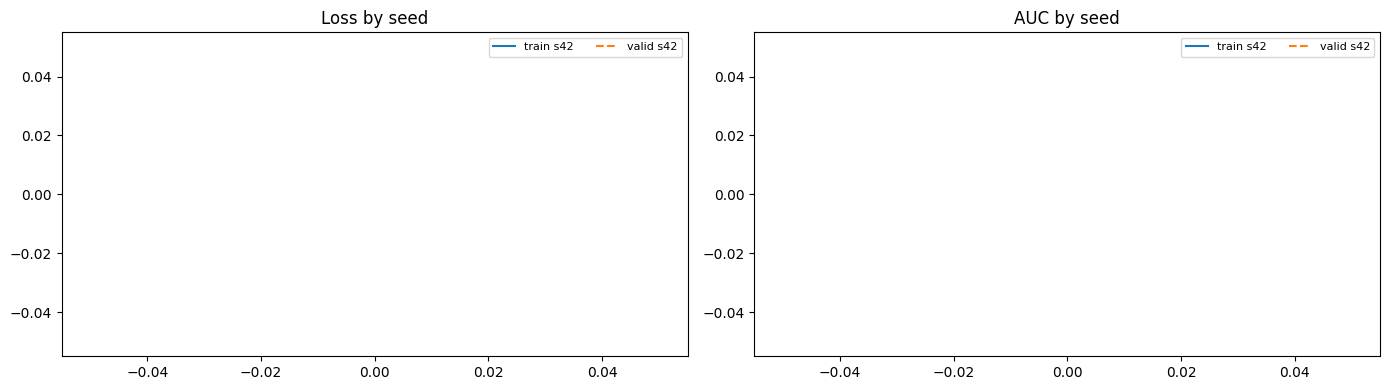

Ensemble validation AUC: 0.9935817592570199
Ensemble test AUC: 0.9902856690983136


In [13]:
seed_runs = []
seed_summaries = []
val_prob_list = []
test_prob_list = []
histories = []

for seed in CFG.ENSEMBLE_SEEDS:
    result = get_or_train_one_seed(seed)
    seed_runs.append(result)
    seed_summaries.append(result["summary"])
    val_prob_list.append(result["val_probs"])
    test_prob_list.append(result["test_probs"])
    histories.append(result["history"])

    # free the model object once probabilities are collected
    del result["model"]
    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

seed_summary_df = pd.DataFrame(seed_summaries)
display(seed_summary_df)

hist = pd.concat(histories, ignore_index=True)
display(hist.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for seed in CFG.ENSEMBLE_SEEDS:
    h = hist[hist["seed"] == seed]
    axes[0].plot(h["epoch"], h["train_loss"], label=f"train s{seed}")
    axes[0].plot(h["epoch"], h["valid_loss"], linestyle="--", label=f"valid s{seed}")
    axes[1].plot(h["epoch"], h["train_auc"], label=f"train s{seed}")
    axes[1].plot(h["epoch"], h["valid_auc"], linestyle="--", label=f"valid s{seed}")

axes[0].set_title("Loss by seed")
axes[0].legend(ncol=2, fontsize=8)
axes[1].set_title("AUC by seed")
axes[1].legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

val_targets = seed_runs[0]["val_targets"]
test_targets = seed_runs[0]["test_targets"]

ensemble_val_probs = np.mean(np.stack(val_prob_list, axis=0), axis=0)
ensemble_test_probs = np.mean(np.stack(test_prob_list, axis=0), axis=0)

print("Ensemble validation AUC:", roc_auc_score(val_targets, ensemble_val_probs))
print("Ensemble test AUC:", roc_auc_score(test_targets, ensemble_test_probs))

np.save(CFG.SAVE_DIR / "ensemble_val_probs.npy", ensemble_val_probs)
np.save(CFG.SAVE_DIR / "ensemble_test_probs.npy", ensemble_test_probs)
np.save(CFG.SAVE_DIR / "val_targets.npy", val_targets)
np.save(CFG.SAVE_DIR / "test_targets.npy", test_targets)
seed_summary_df.to_csv(CFG.SAVE_DIR / "seed_summary.csv", index=False)


In [14]:
def tpr_at_fpr(y_true, y_prob, max_fpr=1e-2):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    valid = np.where(fpr <= max_fpr)[0]
    return float(tpr[valid].max()) if len(valid) else 0.0

def choose_threshold(y_true, y_prob, thresholds=None, objective="f1"):
    if thresholds is None:
        thresholds = CFG.THRESH_GRID

    best_thr = 0.5
    best_score = -np.inf
    rows = []

    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)

        acc = accuracy_score(y_true, pred)
        bal_acc = balanced_accuracy_score(y_true, pred)
        prec = precision_score(y_true, pred, zero_division=0)
        rec = recall_score(y_true, pred, zero_division=0)
        f1 = f1_score(y_true, pred, zero_division=0)

        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        spec = tn / (tn + fp + 1e-12)
        youden = rec + spec - 1.0

        row = {
            "threshold": thr,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "precision": prec,
            "recall": rec,
            "specificity": spec,
            "f1": f1,
            "youden_j": youden,
            "tp": tp, "fp": fp, "tn": tn, "fn": fn
        }
        rows.append(row)

        score = row["f1"] if objective == "f1" else row["youden_j"]
        if score > best_score:
            best_score = score
            best_thr = thr

    return best_thr, pd.DataFrame(rows)

def metric_summary(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensitivity = tp / (tp + fn + 1e-12)
    specificity = tn / (tn + fp + 1e-12)
    precision = precision_score(y_true, y_pred, zero_division=0)
    npv = tn / (tn + fn + 1e-12)

    summary = {
        "threshold": thr,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall_sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "npv": npv,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohen_kappa": cohen_kappa_score(y_true, y_pred),
        "brier_score": brier_score_loss(y_true, y_prob),
        "tpr_at_fpr_1e-2": tpr_at_fpr(y_true, y_prob, 1e-2),
        "tpr_at_fpr_1e-3": tpr_at_fpr(y_true, y_prob, 1e-3),
        "tp": tp, "fp": fp, "tn": tn, "fn": fn,
    }

    report = classification_report(
        y_true, y_pred,
        target_names=["non-lens", "lens"],
        output_dict=True, zero_division=0
    )
    per_class = pd.DataFrame(report).T

    return pd.DataFrame([summary]), per_class, y_pred

best_thr, thr_table = choose_threshold(val_targets, ensemble_val_probs, objective="f1")
display(thr_table.sort_values("f1", ascending=False).head(10))

val_summary, val_per_class, val_preds = metric_summary(val_targets, ensemble_val_probs, thr=best_thr)
print("Chosen threshold from ensembled validation:", best_thr)
display(val_summary)
display(val_per_class)


,threshold,accuracy,balanced_accuracy,precision,recall,specificity,f1,youden_j,tp,fp,tn,fn
146,0.780,0.980270,0.921644,0.808743,0.855491,0.987796,0.831461,0.843288,148,35,2833,25
145,0.775,0.979941,0.921470,0.804348,0.855491,0.987448,0.829132,0.842939,148,36,2832,25
152,0.810,0.980598,0.897376,0.847561,0.803468,0.991283,0.824926,0.794751,139,25,2843,34
151,0.805,0.980270,0.902633,0.834320,0.815029,0.990237,0.824561,0.805266,141,28,2840,32
147,0.785,0.979612,0.913148,0.810056,0.838150,0.988145,0.823864,0.826295,145,34,2834,28
144,0.770,0.978954,0.920947,0.791444,0.855491,0.986402,0.822222,0.841893,148,39,2829,25
149,0.795,0.979612,0.905000,0.820809,0.820809,0.989191,0.820809,0.810000,142,31,2837,31
148,0.790,0.979612,0.905000,0.820809,0.820809,0.989191,0.820809,0.810000,142,31,2837,31
153,0.815,0.980270,0.891770,0.850932,0.791908,0.991632,0.820359,0.783539,137,24,2844,36
150,0.800,0.979612,0.902284,0.824561,0.815029,0.989540,0.819767,0.804569,141,30,2838,32


Chosen threshold from ensembled validation: 0.7799999999999999


,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn
0,0.78,0.993582,0.919252,0.98027,0.921644,0.808743,0.855491,0.987796,0.831461,0.991253,0.821357,0.820991,0.034588,0.815029,0.537572,148,35,2833,25


,precision,recall,f1-score,support
non-lens,0.991253,0.987796,0.989521,2868.00000
lens,0.808743,0.855491,0.831461,173.00000
accuracy,0.980270,0.980270,0.980270,0.98027
macro avg,0.899998,0.921644,0.910491,3041.00000
weighted avg,0.980870,0.980270,0.980530,3041.00000


,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn
0,0.78,0.990286,0.780495,0.989873,0.939041,0.494286,0.887179,0.990902,0.634862,0.99886,0.658044,0.630148,0.032696,0.887179,0.502564,173,177,19278,22


,precision,recall,f1-score,support
non-lens,0.998860,0.990902,0.994865,19455.000000
lens,0.494286,0.887179,0.634862,195.000000
accuracy,0.989873,0.989873,0.989873,0.989873
macro avg,0.746573,0.939041,0.814864,19650.000000
weighted avg,0.993853,0.989873,0.991293,19650.000000


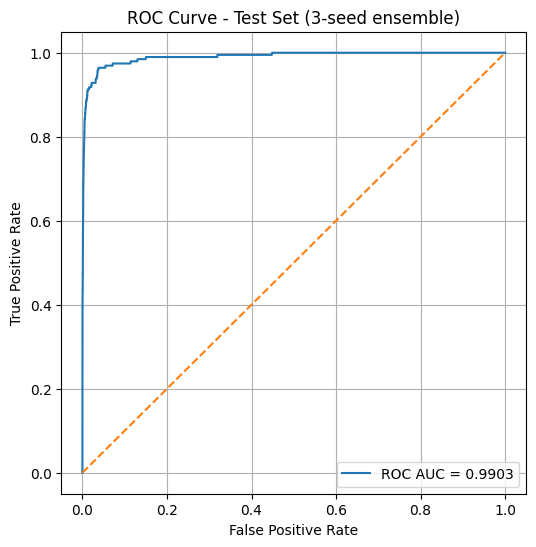

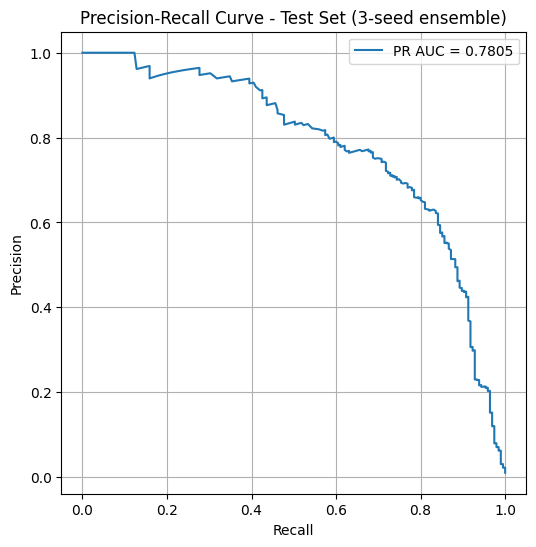

thr=0.300 | TP=190 FP=1740 TN=17715 FN=5 | TPR=0.9744 FPR=0.0894 Precision=0.0984
thr=0.500 | TP=188 FP=858 TN=18597 FN=7 | TPR=0.9641 FPR=0.0441 Precision=0.1797
thr=0.700 | TP=179 FP=336 TN=19119 FN=16 | TPR=0.9179 FPR=0.0173 Precision=0.3476
thr=0.780 | TP=173 FP=179 TN=19276 FN=22 | TPR=0.8872 FPR=0.0092 Precision=0.4915


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


,path,target,prob_ensemble,pred_ensemble
0,/kaggle/input/datasets/aryanaru69/dataset-task...,1,0.874512,1
1,/kaggle/input/datasets/aryanaru69/dataset-task...,1,0.931641,1
2,/kaggle/input/datasets/aryanaru69/dataset-task...,1,0.948242,1
3,/kaggle/input/datasets/aryanaru69/dataset-task...,1,0.865234,1
4,/kaggle/input/datasets/aryanaru69/dataset-task...,1,0.959473,1


In [15]:
test_summary, test_per_class, test_preds = metric_summary(
    test_targets, ensemble_test_probs, thr=best_thr
)
display(test_summary)
display(test_per_class)

fpr, tpr, _ = roc_curve(test_targets, ensemble_test_probs)
prec_curve, rec_curve, _ = precision_recall_curve(test_targets, ensemble_test_probs)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC AUC = {test_summary.loc[0, 'roc_auc']:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set (3-seed ensemble)")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(rec_curve, prec_curve, label=f"PR AUC = {test_summary.loc[0, 'pr_auc']:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Test Set (3-seed ensemble)")
plt.legend()
plt.grid(True)
plt.show()

for thr in [0.30, 0.50, 0.70, float(best_thr)]:
    preds = (ensemble_test_probs >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(test_targets, preds).ravel()
    tpr_ = tp / (tp + fn + 1e-9)
    fpr_ = fp / (fp + tn + 1e-9)
    prec_ = tp / (tp + fp + 1e-9)
    print(
        f"thr={thr:.3f} | TP={tp} FP={fp} TN={tn} FN={fn} | "
        f"TPR={tpr_:.4f} FPR={fpr_:.4f} Precision={prec_:.4f}"
    )

ensemble_outputs = pd.DataFrame({
    "path": test_df["path"],
    "target": test_targets.astype(int),
    "prob_ensemble": ensemble_test_probs,
    "pred_ensemble": test_preds.astype(int),
})
display(ensemble_outputs.head())
ensemble_outputs.to_csv(CFG.SAVE_DIR / "ensemble_test_outputs.csv", index=False)


In [17]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# =========================
# CHOOSE WHICH SPLIT TO ANALYZE
# =========================
# set to "test" or "valid"
split_name = "test"

if split_name == "test":
    split_df = test_df.reset_index(drop=True).copy()
    y_true = np.asarray(test_targets).astype(int)
    y_prob = np.asarray(ensemble_test_probs).astype(float)
elif split_name == "valid":
    split_df = val_df.reset_index(drop=True).copy()
    y_true = np.asarray(val_targets).astype(int)
    y_prob = np.asarray(ensemble_val_probs).astype(float)
else:
    raise ValueError("split_name must be 'test' or 'valid'")

thr = float(best_thr) if "best_thr" in globals() else 0.5
y_pred = (y_prob >= thr).astype(int)

if len(split_df) != len(y_true):
    raise ValueError(f"Length mismatch: len(split_df)={len(split_df)} vs len(y_true)={len(y_true)}")

analysis_df = split_df.copy()
analysis_df["target"] = y_true
analysis_df["prob"] = y_prob
analysis_df["pred"] = y_pred

def outcome_name(t, p):
    if t == 1 and p == 1:
        return "TP"
    if t == 0 and p == 1:
        return "FP"
    if t == 1 and p == 0:
        return "FN"
    return "TN"

analysis_df["outcome"] = [outcome_name(t, p) for t, p in zip(y_true, y_pred)]
analysis_df["error"] = (analysis_df["target"] != analysis_df["pred"]).astype(int)
analysis_df["confidence"] = np.where(analysis_df["pred"] == 1, analysis_df["prob"], 1.0 - analysis_df["prob"])

tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

print(f"Split: {split_name}")
print(f"Threshold: {thr:.4f}")
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")

print("\nCounts by outcome:")
print(analysis_df["outcome"].value_counts())

os.makedirs("/kaggle/working/error_analysis", exist_ok=True)
csv_path = f"/kaggle/working/error_analysis/{split_name}_error_analysis.csv"
analysis_df.to_csv(csv_path, index=False)
print(f"\nSaved analysis CSV to: {csv_path}")

display(analysis_df.head())

Split: test
Threshold: 0.7800
TP=173  FP=177  TN=19278  FN=22

Counts by outcome:
outcome
TN    19278
FP      177
TP      173
FN       22
Name: count, dtype: int64

Saved analysis CSV to: /kaggle/working/error_analysis/test_error_analysis.csv


,path,label,split,folder,target,prob,pred,outcome,error,confidence
0,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.874512,1,TP,0,0.874512
1,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.931641,1,TP,0,0.931641
2,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.948242,1,TP,0,0.948242
3,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.865234,1,TP,0,0.865234
4,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.959473,1,TP,0,0.959473


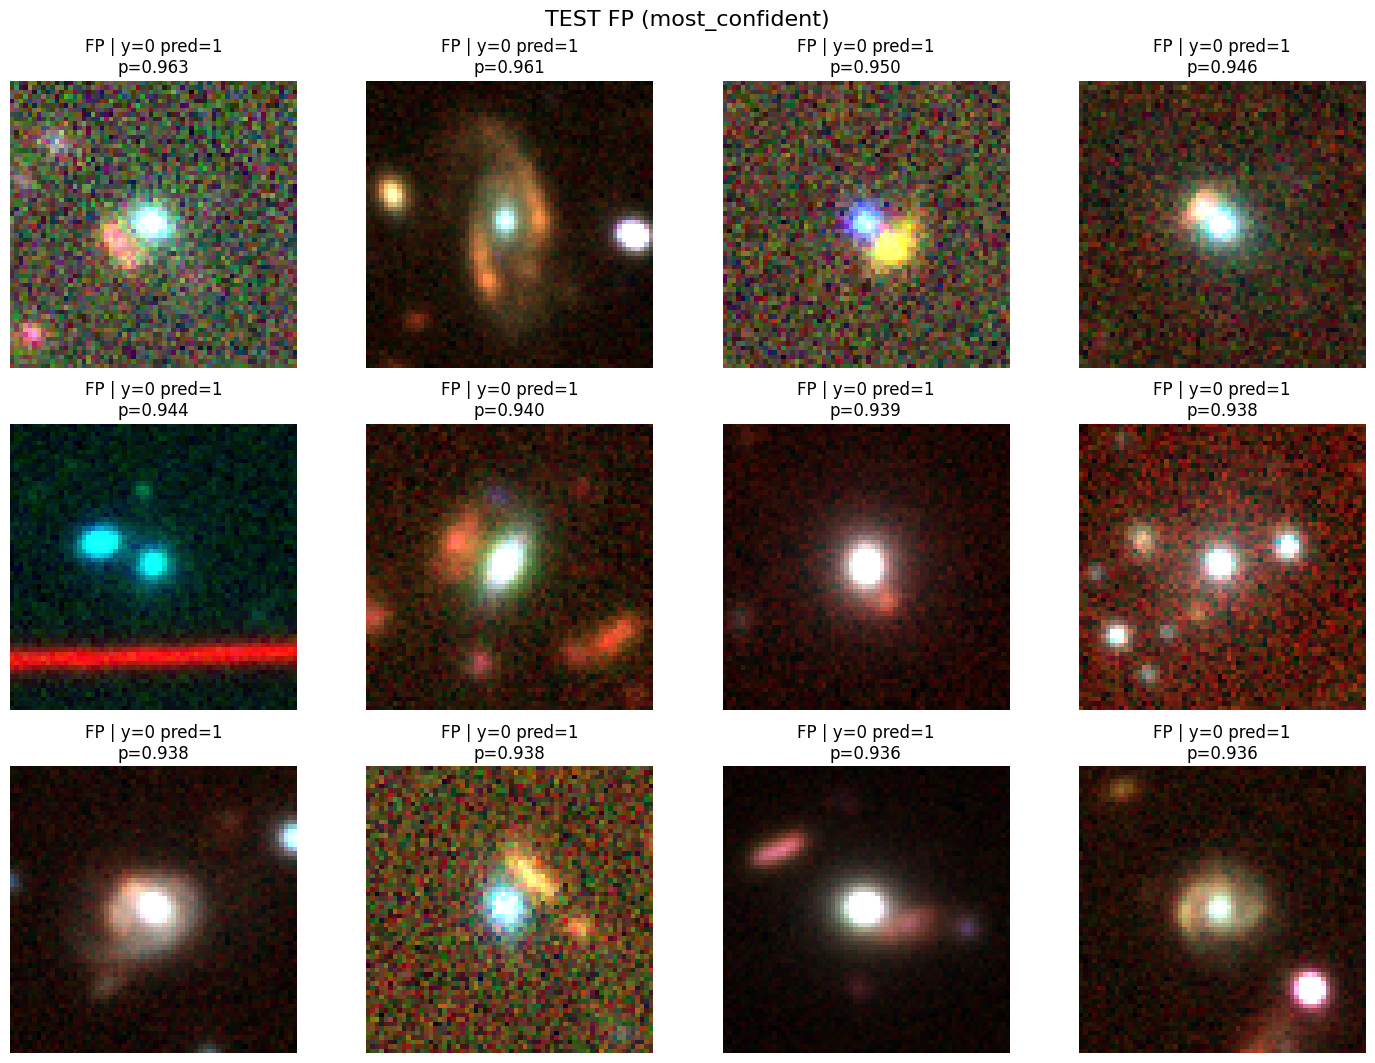

Saved: /kaggle/working/error_analysis/test_FP_most_confident_rgb.png


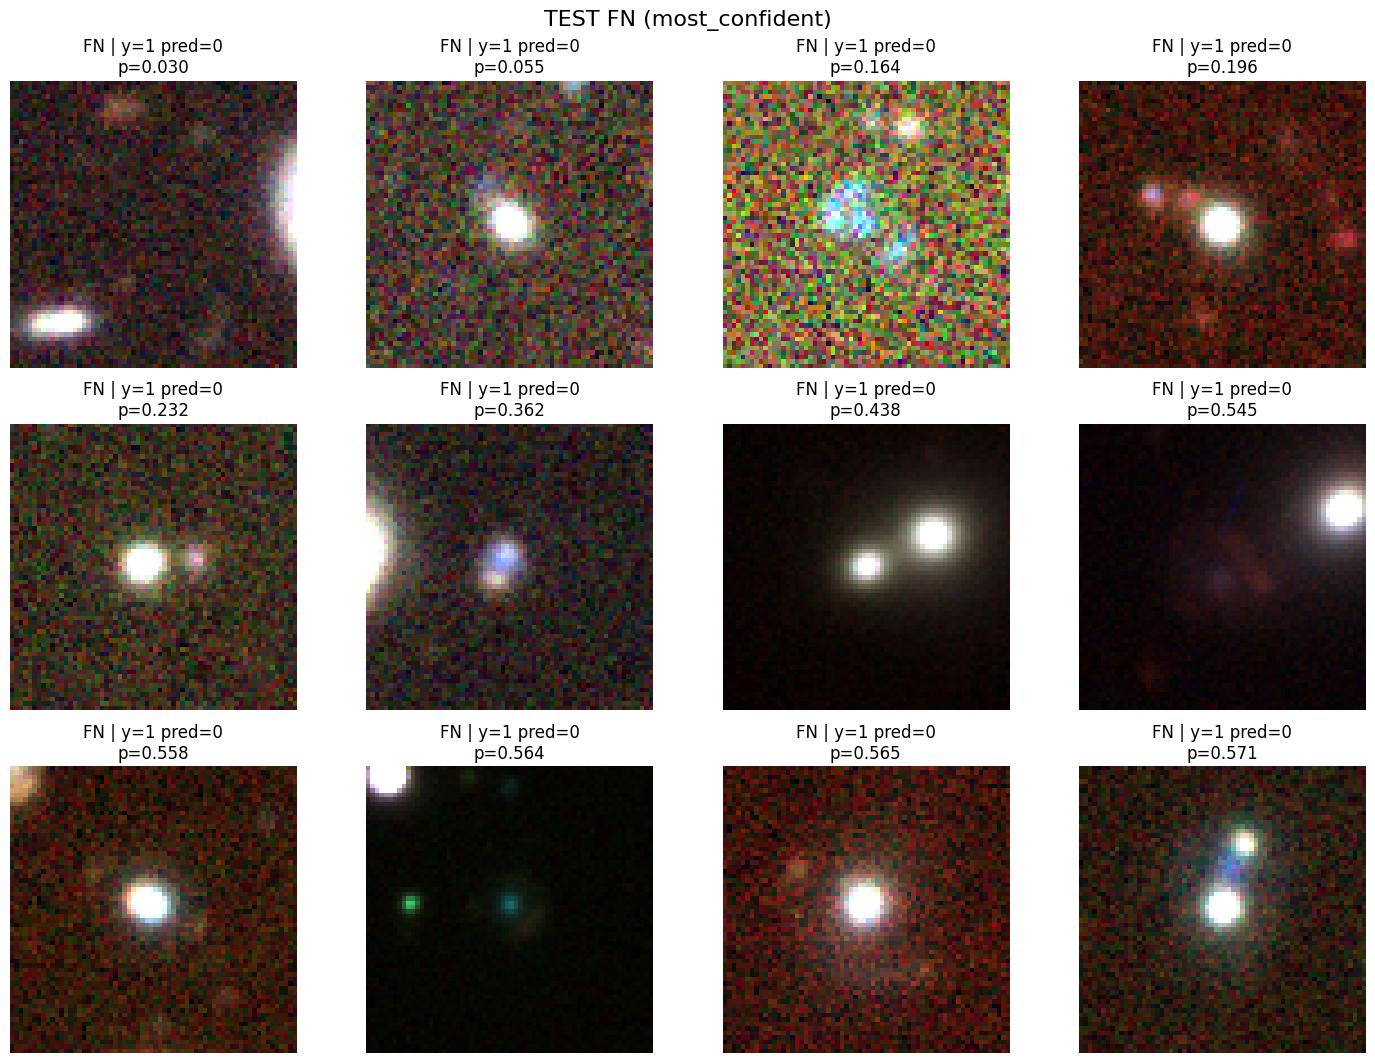

Saved: /kaggle/working/error_analysis/test_FN_most_confident_rgb.png


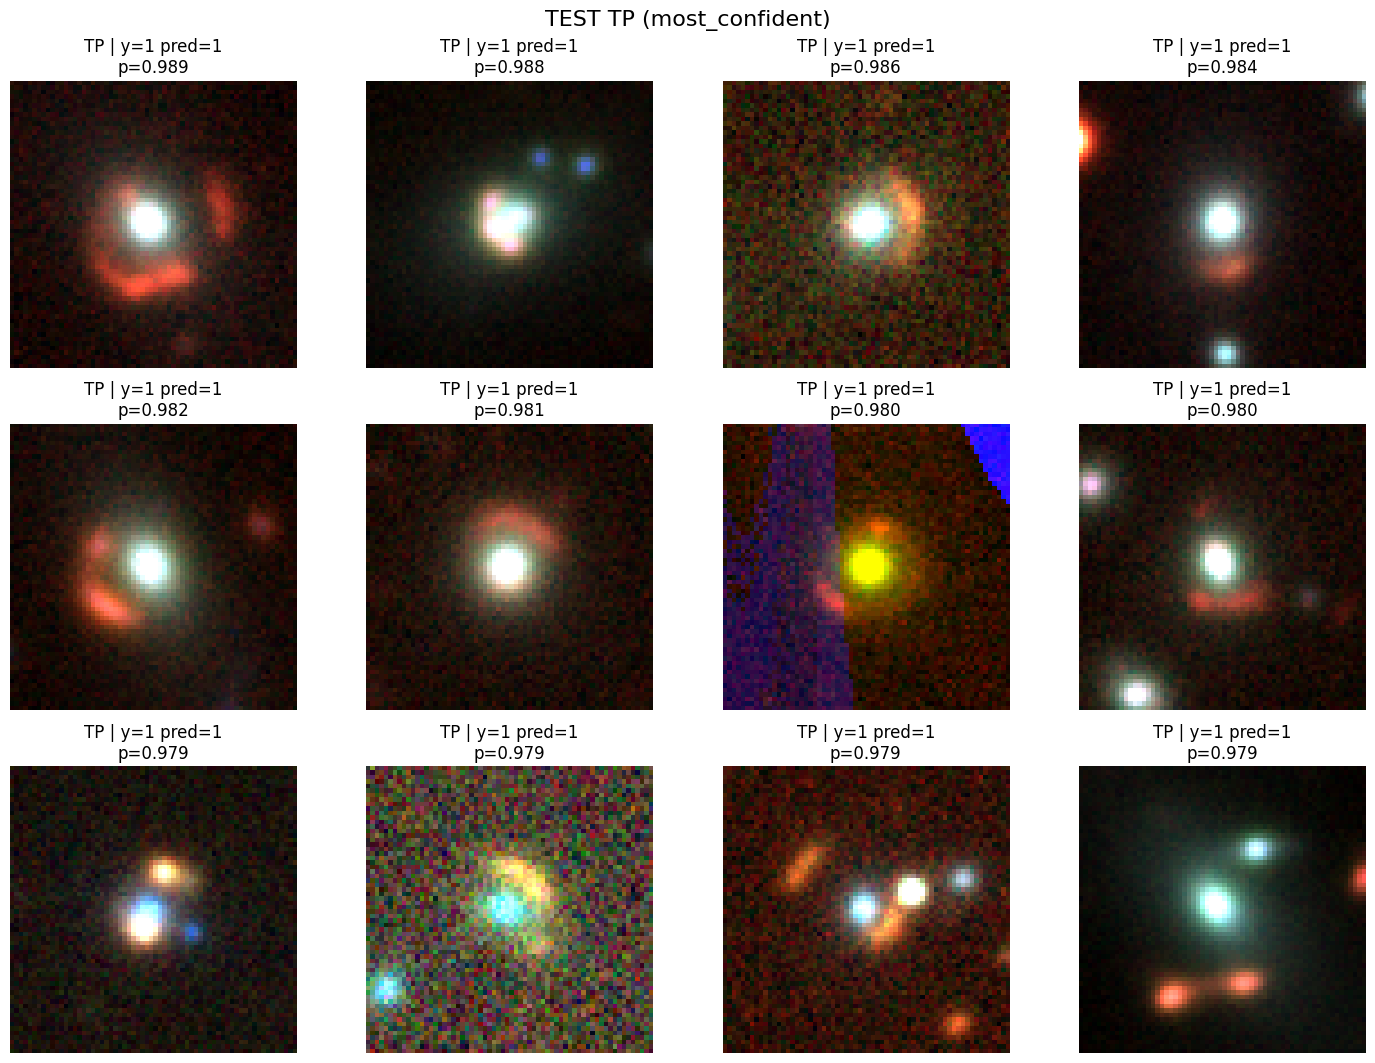

Saved: /kaggle/working/error_analysis/test_TP_most_confident_rgb.png


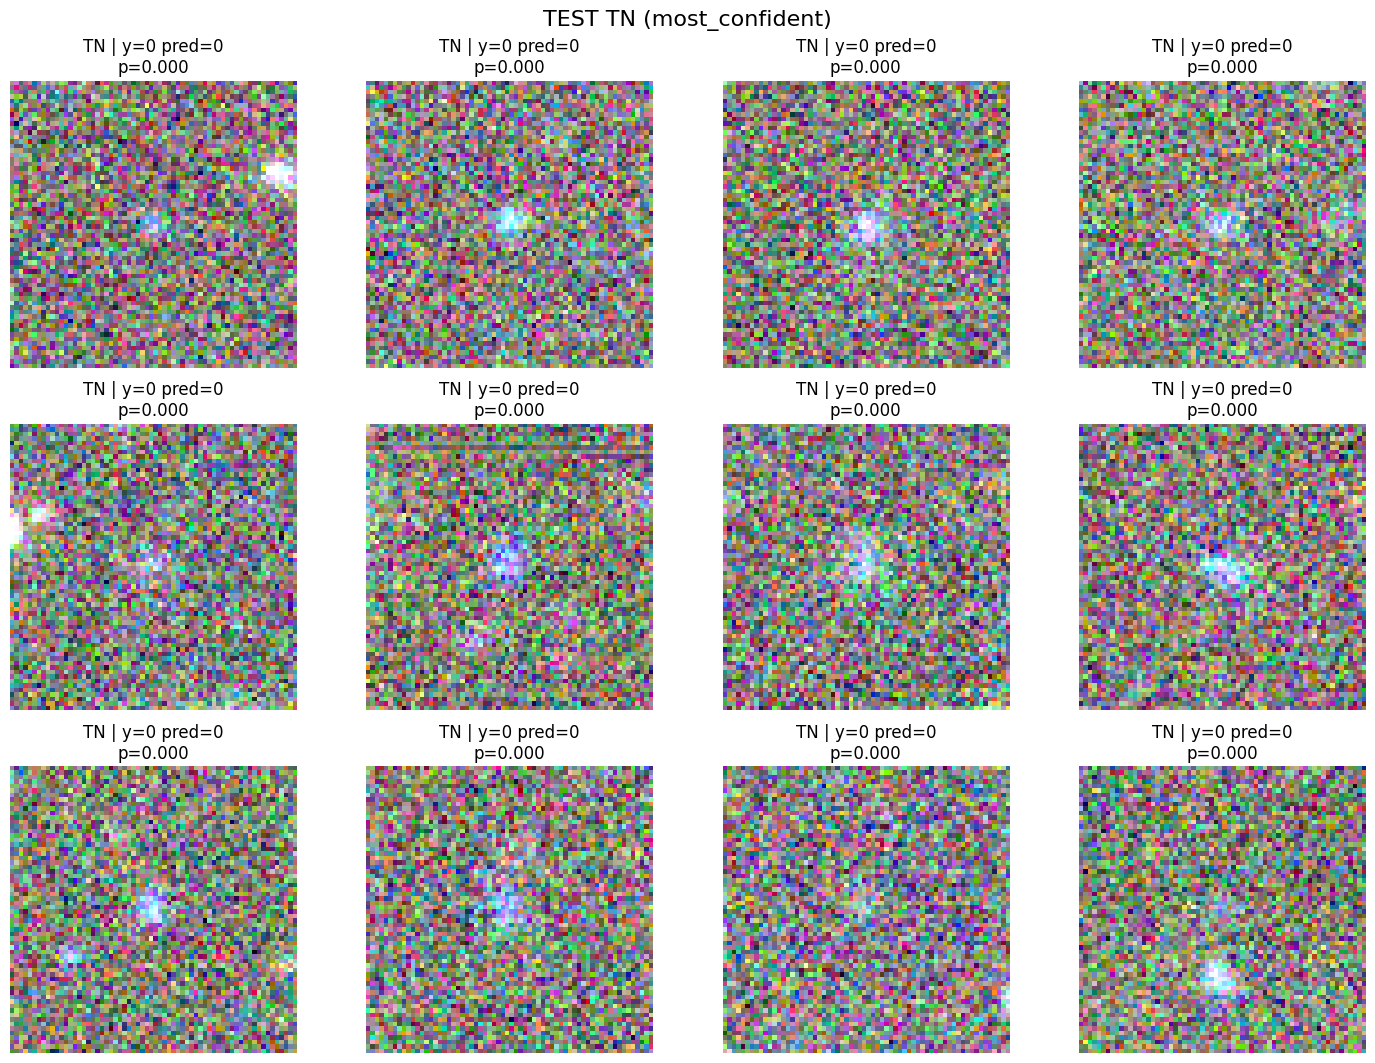

Saved: /kaggle/working/error_analysis/test_TN_most_confident_rgb.png


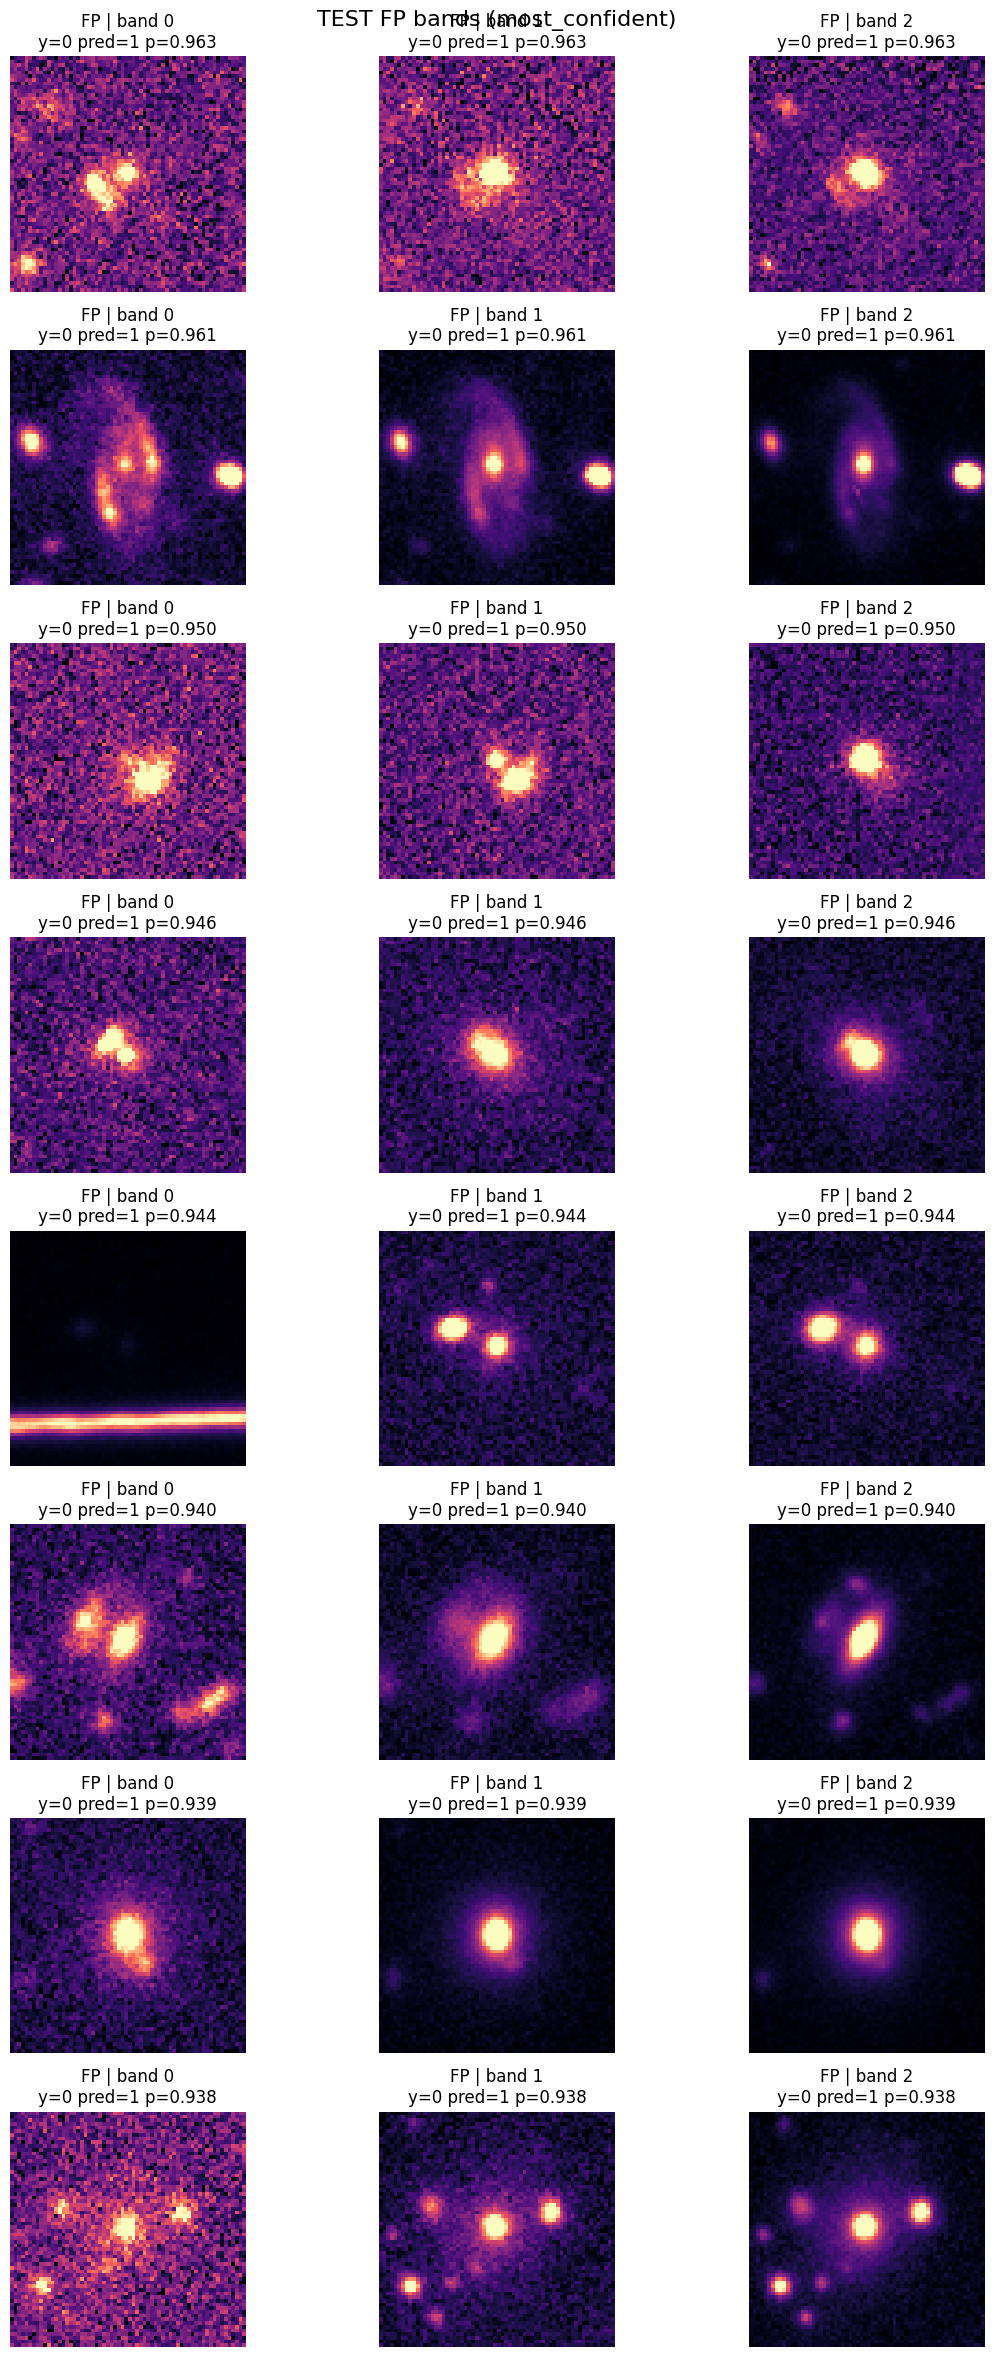

Saved: /kaggle/working/error_analysis/test_FP_most_confident_bands.png


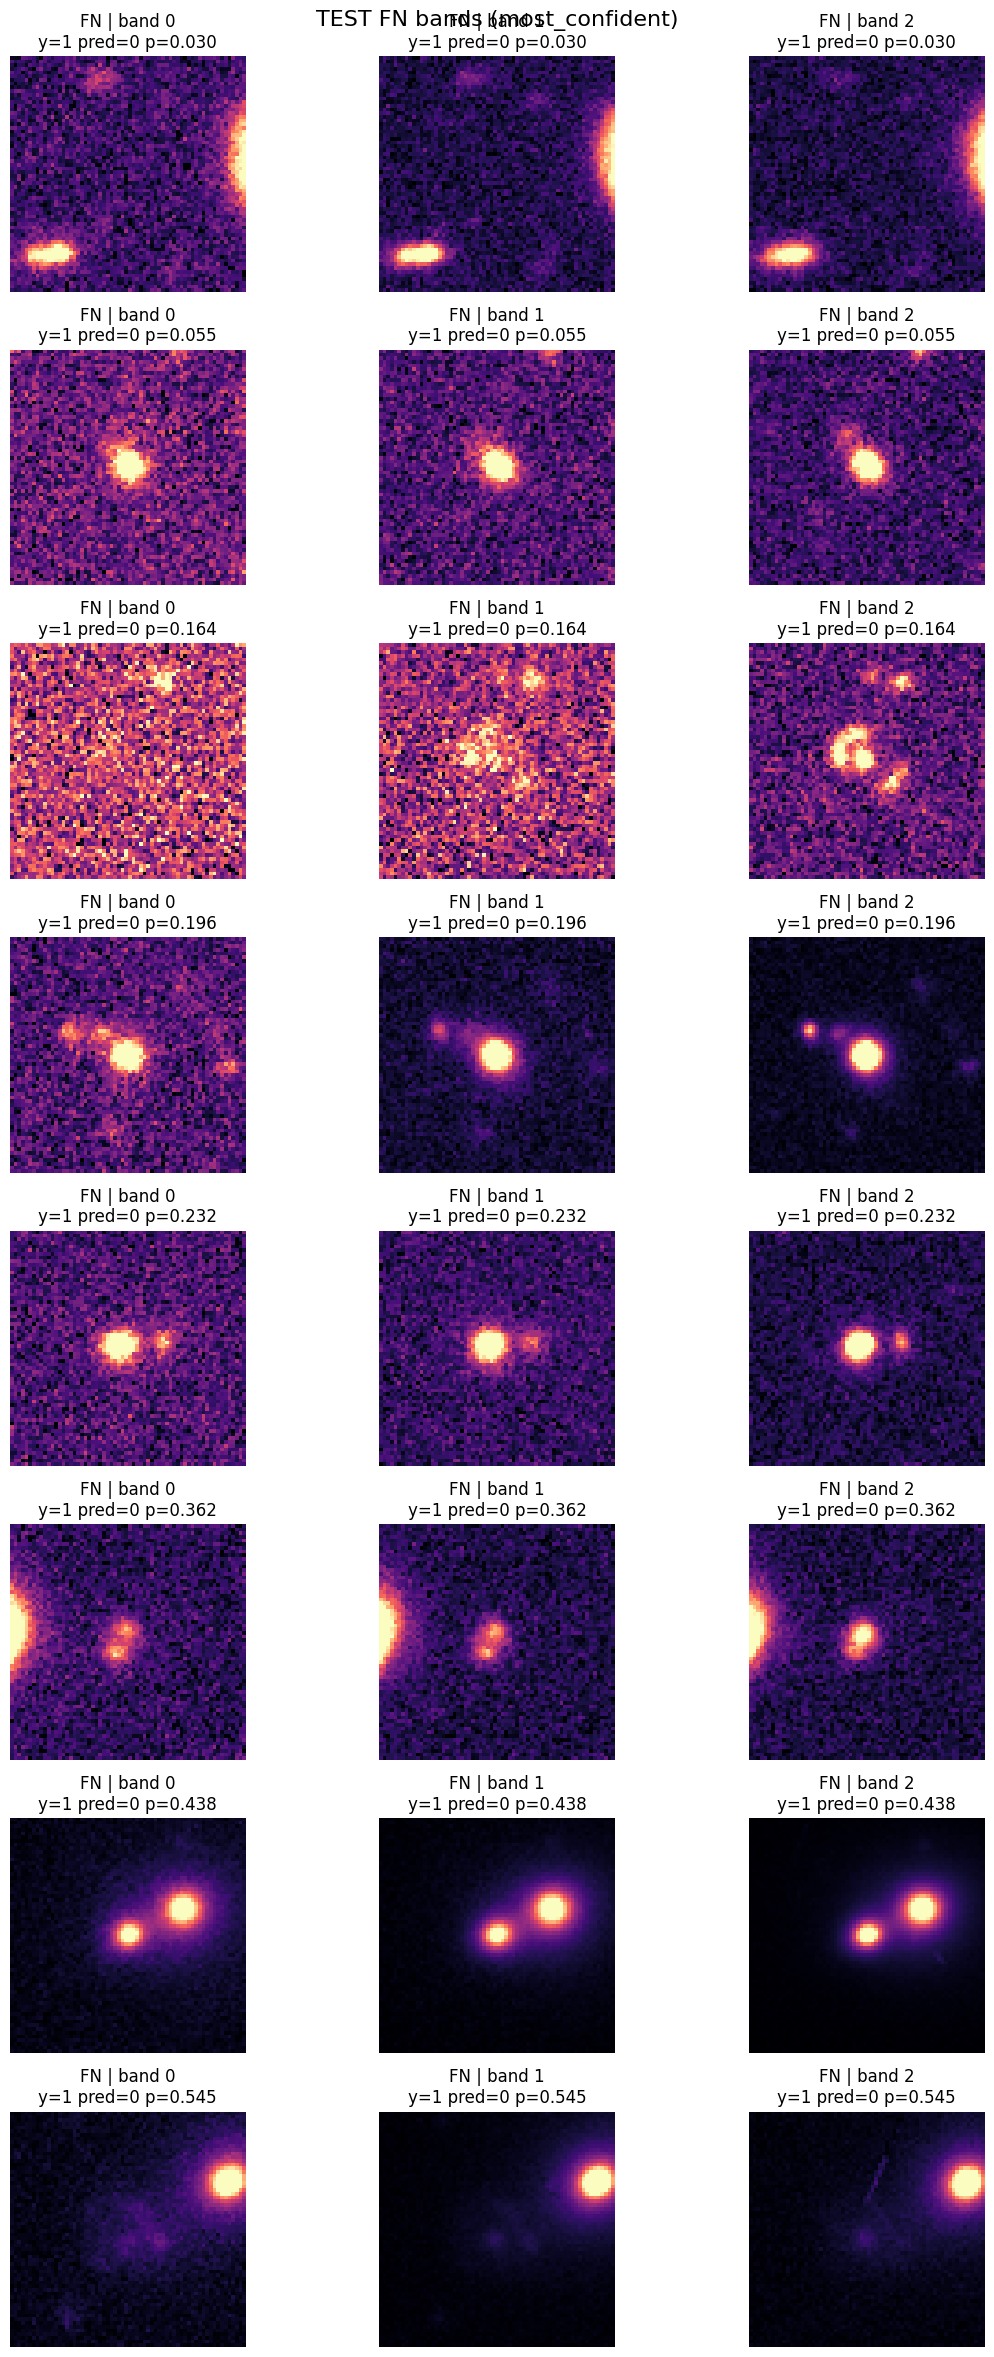

Saved: /kaggle/working/error_analysis/test_FN_most_confident_bands.png


In [18]:
import math
import matplotlib.pyplot as plt

def _to_rgb_for_display(x):
    # x expected [3,H,W] in [0,1]
    rgb = np.stack([x[0], x[1], x[2]], axis=-1)
    return np.clip(rgb, 0, 1)

def show_outcome_gallery(
    analysis_df,
    outcome="FP",
    n=12,
    sort_mode="most_confident",
    bands=False,
    save=True,
    figsize_scale=3.6
):
    """
    outcome: TP / FP / FN / TN
    sort_mode:
        - "most_confident"  : strongest examples of that outcome
        - "least_confident" : weakest examples of that outcome
        - "random"          : random examples
    bands:
        - False -> pseudo-RGB
        - True  -> show 3 bands per sample
    """
    sub = analysis_df[analysis_df["outcome"] == outcome].copy()

    if len(sub) == 0:
        print(f"No samples for outcome={outcome}")
        return

    # sensible default ordering
    if sort_mode == "most_confident":
        if outcome in ["FP", "TP"]:
            sub = sub.sort_values("prob", ascending=False)
        else:  # FN, TN
            sub = sub.sort_values("prob", ascending=True)
    elif sort_mode == "least_confident":
        if outcome in ["FP", "TP"]:
            sub = sub.sort_values("prob", ascending=True)
        else:
            sub = sub.sort_values("prob", ascending=False)
    elif sort_mode == "random":
        sub = sub.sample(frac=1.0, random_state=42)
    else:
        raise ValueError("sort_mode must be most_confident / least_confident / random")

    sub = sub.head(min(n, len(sub))).reset_index(drop=True)

    if not bands:
        cols = 4
        rows = math.ceil(len(sub) / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(figsize_scale * cols, figsize_scale * rows))
        axes = np.array(axes).reshape(-1)

        for ax, (_, row) in zip(axes, sub.iterrows()):
            x = load_npy(row.path)
            x = astrophysical_stretch(x)
            ax.imshow(_to_rgb_for_display(x))
            ax.set_title(
                f"{row.outcome} | y={int(row.target)} pred={int(row.pred)}\n"
                f"p={row.prob:.3f}"
            )
            ax.axis("off")

        for ax in axes[len(sub):]:
            ax.axis("off")

        plt.suptitle(f"{split_name.upper()} {outcome} ({sort_mode})", fontsize=16)
        plt.tight_layout()
        plt.show()

        if save:
            out_path = f"/kaggle/working/error_analysis/{split_name}_{outcome}_{sort_mode}_rgb.png"
            fig.savefig(out_path, dpi=180, bbox_inches="tight")
            print("Saved:", out_path)

    else:
        rows = len(sub)
        fig, axes = plt.subplots(rows, 3, figsize=(12, 3 * rows))
        if rows == 1:
            axes = np.array([axes])

        for i, (_, row) in enumerate(sub.iterrows()):
            x = load_npy(row.path)
            x = astrophysical_stretch(x)

            for c in range(3):
                axes[i, c].imshow(x[c], cmap="magma")
                axes[i, c].set_title(
                    f"{row.outcome} | band {c}\n"
                    f"y={int(row.target)} pred={int(row.pred)} p={row.prob:.3f}"
                )
                axes[i, c].axis("off")

        plt.suptitle(f"{split_name.upper()} {outcome} bands ({sort_mode})", fontsize=16)
        plt.tight_layout()
        plt.show()

        if save:
            out_path = f"/kaggle/working/error_analysis/{split_name}_{outcome}_{sort_mode}_bands.png"
            fig.savefig(out_path, dpi=180, bbox_inches="tight")
            print("Saved:", out_path)

# =========================
# RUN ALL FOUR OUTCOME GALLERIES
# =========================
for outcome in ["FP", "FN", "TP", "TN"]:
    show_outcome_gallery(
        analysis_df,
        outcome=outcome,
        n=12,
        sort_mode="most_confident",
        bands=False,   # pseudo-RGB
        save=True
    )

# Optional: inspect the hardest mistakes band-by-band
show_outcome_gallery(analysis_df, outcome="FP", n=8, sort_mode="most_confident", bands=True, save=True)
show_outcome_gallery(analysis_df, outcome="FN", n=8, sort_mode="most_confident", bands=True, save=True)

## Mermaid: 3-seed ensemble notebook

```mermaid
flowchart TD
    A[Load .npy cutouts] --> B[Asinh stretch + robust normalization]
    B --> C[Fixed 90:10 stratified split inside train folders]
    C --> D[For each seed: 42, 1337, 2029]
    D --> E[Weighted sampler + identical augmentations]
    E --> F[DensePolarNet-Robust]
    F --> F1[DenseNet-161 small stem]
    F --> F2[Polar branch]
    F --> F3[Radial statistics branch]
    F1 --> G[Fusion head]
    F2 --> G
    F3 --> G
    G --> H[Focal loss + AdamW + Cosine LR + EMA]
    H --> I[D4 TTA predictions per seed]
    I --> J[Average seed probabilities]
    J --> K[Choose threshold on ensembled validation only]
    K --> L[Final test ROC-AUC / PR-AUC / confusion metrics]
```


## CaLiCo-Lens Stage B: Contaminant-Aware Lens-Consistency Verification

**What this prototype adds**

Instead of only asking *“does this cutout look lens-like?”*, Stage B asks:

1. **Can the candidate be centered and canonicalized into a geometry-consistent annular view?**
2. **Do the sectors around the putative annulus behave relationally like lensed structure rather than random contaminants?**
3. **If it is not a lens, does it resemble one of a small number of mined contaminant families?**

This implementation is intentionally **single-seed first** so you can test viability before spending more Kaggle hours.

**Design choices**
- Reuse the frozen **Stage-A DensePolarNet-Robust** encoder and checkpoint.
- Mine **hard train negatives** from Stage-A scores and cluster them into a **coarse pseudo-taxonomy** of contaminants.
- Predict a **weak lens geometry proxy** `(dx, dy, r0, q, phi)`.
- Build an **elliptic-polar canonicalized view** centered on the predicted annulus.
- Learn an **arcness map** and **angular sector relations** in canonical space.
- Train a final verifier with:
  - lens classification loss,
  - relation classification loss,
  - weak center/radius regularization,
  - weak arcness regularization,
  - contaminant auxiliary loss.

This is a **research-backed but still exploratory** prototype. It is meant to be a realistic paper-starting point, not a guaranteed improvement over the best existing ensemble.


In [26]:
class CALICO_CFG:
    BASE_SEED = 42
    TRAIN_STAGE_A_IF_MISSING = False
    USE_HF_STAGE_A = True
    FORCE_STAGE_A_RETRAIN = False

    # mining / pseudo-taxonomy
    HARDNEG_TOP_FRAC = 0.03
    HARDNEG_MIN_COUNT = 256
    CONTAM_K = 4
    CONTAM_MIN_SAMPLES = 48

    # Stage B architecture  ---------------------------
    CANON_RADIAL_BINS = 32
    CANON_ANGULAR_BINS = 64
    CANON_WINDOW = 0.70
    N_SECTORS = 16

    # EXPERIMENT 3: smaller transformer
    TOKEN_DIM = 128
    TRANSFORMER_LAYERS = 1
    TRANSFORMER_HEADS = 4
    TRANSFORMER_MLP = 256
    DROPOUT = 0.20

    # training  --------------------------------------
    # EXPERIMENT 4: slightly longer runway
    EPOCHS = 12
    BATCH_SIZE = 20
    LR = 1.5e-4
    WEIGHT_DECAY = 1e-4
    PATIENCE = 6
    AMP = True
    CLIP_GRAD_NORM = 1.0
    FREEZE_STAGE_A = True

    # losses  ----------------------------------------
    # EXPERIMENT 2: reduce auxiliary pressure
    W_MAIN = 1.0
    W_REL = 0.10
    W_CONTAM = 0.10
    W_CENTER = 0.02
    W_RADIUS = 0.02
    W_ARC = 0.02

    SAVE_DIR = Path("/kaggle/working/calico_lens_single_seed_tuned")
    SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("CALICO_CFG ready:", CALICO_CFG.SAVE_DIR)

CALICO_CFG ready: /kaggle/working/calico_lens_single_seed_tuned


In [27]:

# =========================
# Stage A feature extractor (weight-compatible with DensePolarNetRobust)
# =========================
class DensePolarNetStageAFeatures(nn.Module):
    def __init__(self, model_name="densenet161", pretrained=False, small_image_stem=True,
                 use_polar_branch=True, use_radial_branch=True, memory_efficient=True):
        super().__init__()
        self.use_polar_branch = use_polar_branch
        self.use_radial_branch = use_radial_branch

        if model_name == "densenet121":
            weights = DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet121(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet121(weights=None, memory_efficient=memory_efficient)
        elif model_name == "densenet161":
            weights = DenseNet161_Weights.IMAGENET1K_V1 if pretrained else None
            try:
                self.backbone = densenet161(weights=weights, memory_efficient=memory_efficient)
            except Exception:
                self.backbone = densenet161(weights=None, memory_efficient=memory_efficient)
        else:
            raise ValueError("model_name must be 'densenet121' or 'densenet161'")

        dense_dim = self.backbone.classifier.in_features

        if small_image_stem:
            old = self.backbone.features.conv0
            self.backbone.features.conv0 = nn.Conv2d(
                3, old.out_channels, kernel_size=3, stride=1, padding=1, bias=False
            )
            self.backbone.features.pool0 = nn.Identity()

        self.backbone.classifier = nn.Identity()

        polar_dim = 0
        radial_dim = 0

        if self.use_polar_branch:
            self.polar = PolarTransform(radial_bins=32, angular_bins=64)
            self.polar_cnn = nn.Sequential(
                PolarConvBNAct(3, 32, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(32, 64, 3),
                nn.MaxPool2d(2),
                PolarConvBNAct(64, 128, 3),
                nn.AdaptiveAvgPool2d((1, 1))
            )
            polar_dim = 128

        if self.use_radial_branch:
            self.radial_head = nn.Sequential(
                nn.Conv1d(6, 32, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(32),
                nn.ReLU(inplace=True),
                nn.Conv1d(32, 64, kernel_size=5, padding=2, bias=False),
                nn.BatchNorm1d(64),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool1d(1)
            )
            radial_dim = 64

        fused_dim = dense_dim + polar_dim + radial_dim
        self.fusion_gate = FusionGate(fused_dim, reduction=8)
        self.head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(256, 1)
        )
        self.fused_dim = fused_dim
        self.dense_dim = dense_dim
        self.polar_dim = polar_dim
        self.radial_dim = radial_dim

    def forward_dict(self, x):
        feat_map = self.backbone.features(x)
        feat_map = F.relu(feat_map, inplace=False)
        dense_feat = F.adaptive_avg_pool2d(feat_map, (1, 1)).flatten(1)

        feats = [dense_feat]
        polar = None
        radial_profile = None
        polar_feat = None
        radial_feat = None

        if self.use_polar_branch:
            polar = self.polar(x)                       # [B, 3, R, T]
            polar_feat = self.polar_cnn(polar).flatten(1)
            feats.append(polar_feat)

            if self.use_radial_branch:
                radial_mean = polar.mean(dim=-1)       # [B, 3, R]
                radial_std = polar.std(dim=-1, unbiased=False)
                radial = torch.cat([radial_mean, radial_std], dim=1)
                radial_feat = self.radial_head(radial).flatten(1)
                feats.append(radial_feat)
                radial_profile = polar.mean(dim=1).mean(dim=-1)  # [B, R]

        fused = torch.cat(feats, dim=1)
        fused = self.fusion_gate(fused)
        stage_a_logit = self.head(fused).squeeze(1)

        return {
            "feat_map": feat_map,
            "dense_feat": dense_feat,
            "polar": polar,
            "polar_feat": polar_feat,
            "radial_feat": radial_feat,
            "radial_profile": radial_profile,
            "fused": fused,
            "stage_a_logit": stage_a_logit,
        }

    def forward(self, x):
        return self.forward_dict(x)["stage_a_logit"]


def build_stage_a_feature_extractor():
    model = DensePolarNetStageAFeatures(
        model_name=CFG.MODEL_NAME,
        pretrained=False,
        small_image_stem=CFG.SMALL_IMAGE_STEM,
        use_polar_branch=CFG.USE_POLAR_BRANCH,
        use_radial_branch=CFG.USE_RADIAL_BRANCH,
        memory_efficient=CFG.MEMORY_EFFICIENT,
    ).to(device)
    return model



def get_stage_a_ckpt(seed=42):
    ckpt_path = get_or_download_stage_a_ckpt(seed)
    if ckpt_path.exists():
        return ckpt_path

    if CALICO_CFG.TRAIN_STAGE_A_IF_MISSING:
        print(f"Stage-A checkpoint not found. Training single seed {seed}...")
        result = train_one_seed(seed)
        ckpt_path = CFG.SAVE_DIR / f"best_densepolar_robust_seed_{seed}.pt"
        if "model" in result:
            del result["model"]
        gc.collect()
        if device.type == "cuda":
            torch.cuda.empty_cache()
        if ckpt_path.exists():
            return ckpt_path

    raise FileNotFoundError(
        f"Missing Stage-A checkpoint: {ckpt_path}. "
        "Provide it locally, in the HF artifact repo, or set CALICO_CFG.TRAIN_STAGE_A_IF_MISSING=True."
    )


def load_stage_a_model(seed=42):
    ckpt_path = get_stage_a_ckpt(seed)
    model = build_stage_a_feature_extractor()
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state, strict=True)
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    print(f"Loaded Stage-A checkpoint: {ckpt_path}")
    return model


# =========================
# Mining features / pseudo contaminant taxonomy
# =========================
class LensDatasetWithMeta(Dataset):
    def __init__(self, df, augment=False, contam_labels=None):
        self.df = df.reset_index(drop=True).copy()
        self.augment = augment
        if contam_labels is None:
            contam_labels = np.full(len(self.df), -1, dtype=np.int64)
        self.contam_labels = np.asarray(contam_labels, dtype=np.int64)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        x = load_npy(row.path)

        if self.augment:
            x = random_rot90(x)
            x = random_flip(x)
            x = random_shift(x, CFG.MAX_SHIFT)

        x = astrophysical_stretch(x)

        if self.augment:
            x = random_gain_jitter(x)
            x = random_band_dropout(x)
            x = random_noise(x)

        x = torch.tensor(x, dtype=torch.float32)
        y = torch.tensor(float(row.label), dtype=torch.float32)
        c = torch.tensor(int(self.contam_labels[idx]), dtype=torch.long)
        return x, y, c


def make_meta_loader(df, contam_labels=None, batch_size=None, shuffle=False):
    ds = LensDatasetWithMeta(df, augment=False, contam_labels=contam_labels)
    loader = DataLoader(
        ds,
        batch_size=batch_size or (CFG.BATCH_SIZE * 2),
        shuffle=shuffle,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    return loader


@torch.inference_mode()
def collect_stage_a_outputs(model, df, batch_size=None):
    loader = make_meta_loader(df, contam_labels=None, batch_size=batch_size, shuffle=False)

    probs = []
    fused = []
    radial_profiles = []
    paths = list(df["path"].values)
    labels = df["label"].values.astype(int)

    for x, y, _ in loader:
        x = x.to(device, non_blocking=True)
        out = model.forward_dict(x)
        probs.append(torch.sigmoid(out["stage_a_logit"]).cpu().numpy())
        fused.append(out["fused"].cpu().numpy())
        if out["radial_profile"] is not None:
            radial_profiles.append(out["radial_profile"].cpu().numpy())

    probs = np.concatenate(probs, axis=0)
    fused = np.concatenate(fused, axis=0)
    radial_profiles = np.concatenate(radial_profiles, axis=0) if len(radial_profiles) else None

    res = pd.DataFrame({
        "path": paths,
        "label": labels,
        "stage_a_prob": probs,
    })
    return res, fused, radial_profiles


def mine_hard_negative_clusters(train_meta_df, train_fused, top_frac=0.03, min_count=256, n_clusters=4):
    neg_mask = train_meta_df["label"].values == 0
    neg_probs = train_meta_df.loc[neg_mask, "stage_a_prob"].values
    neg_idx = np.where(neg_mask)[0]

    n_keep = max(min_count, int(len(neg_idx) * top_frac))
    n_keep = min(n_keep, len(neg_idx))

    order = np.argsort(-neg_probs)
    hard_idx = neg_idx[order[:n_keep]]

    if len(hard_idx) < max(16, n_clusters):
        print("Not enough hard negatives for clustering; contaminant head will be disabled.")
        return None

    k = min(n_clusters, len(hard_idx))
    km = KMeans(n_clusters=k, random_state=CALICO_CFG.BASE_SEED, n_init=10)
    hard_feats = train_fused[hard_idx]
    hard_labels = km.fit_predict(hard_feats)

    contam_labels = np.full(len(train_meta_df), -1, dtype=np.int64)
    contam_labels[hard_idx] = hard_labels

    hard_df = train_meta_df.iloc[hard_idx].copy()
    hard_df["contam_cluster"] = hard_labels
    return {
        "kmeans": km,
        "hard_idx": hard_idx,
        "contam_labels": contam_labels,
        "hard_df": hard_df,
    }


def assign_clusters_by_nearest(df_meta, fused_feats, km, score_floor=None):
    labels = np.full(len(df_meta), -1, dtype=np.int64)
    if km is None:
        return labels

    if score_floor is None:
        mask = df_meta["label"].values == 0
    else:
        mask = (df_meta["label"].values == 0) & (df_meta["stage_a_prob"].values >= score_floor)

    if mask.sum() == 0:
        return labels

    labels[mask] = km.predict(fused_feats[mask])
    return labels


def plot_contaminant_cluster_gallery(df_meta, contam_labels, n_per_cluster=8, title_prefix="train hard negatives"):
    valid = contam_labels >= 0
    if valid.sum() == 0:
        print("No contaminant labels to visualize.")
        return

    tmp = df_meta.copy()
    tmp["contam_cluster"] = contam_labels
    clusters = sorted(tmp.loc[tmp["contam_cluster"] >= 0, "contam_cluster"].unique())

    for c in clusters:
        sub = tmp[tmp["contam_cluster"] == c].head(n_per_cluster)
        cols = min(4, len(sub))
        rows = int(np.ceil(len(sub) / max(cols, 1)))
        fig, axes = plt.subplots(rows, cols, figsize=(3 * max(cols, 1), 3 * max(rows, 1)))
        axes = np.array(axes).reshape(-1)
        for ax, (_, row) in zip(axes, sub.iterrows()):
            x = astrophysical_stretch(load_npy(row.path))
            ax.imshow(np.stack([x[0], x[1], x[2]], axis=-1))
            ax.set_title(f"cluster {c}\np={row.stage_a_prob:.3f}")
            ax.axis("off")
        for ax in axes[len(sub):]:
            ax.axis("off")
        plt.suptitle(f"{title_prefix} - cluster {c}", fontsize=14)
        plt.tight_layout()
        plt.show()


# =========================
# Geometry / canonicalization / relation modules
# =========================
def estimate_centroid_batch(x):
    # x: [B, 3, H, W] in [0, 1]
    gray = x.mean(dim=1)
    weights = gray ** 2
    b, h, w = gray.shape
    yy = torch.linspace(-1.0, 1.0, h, device=x.device).view(1, h, 1)
    xx = torch.linspace(-1.0, 1.0, w, device=x.device).view(1, 1, w)
    denom = weights.sum(dim=(1, 2), keepdim=True) + 1e-6
    cy = (weights * yy).sum(dim=(1, 2), keepdim=True) / denom
    cx = (weights * xx).sum(dim=(1, 2), keepdim=True) / denom
    return torch.cat([cx, cy], dim=1).squeeze(-1)


def estimate_radial_peak_from_profile(radial_profile):
    # radial_profile: [B, R]
    if radial_profile is None:
        return None
    rp = radial_profile.clone()
    if rp.shape[1] > 4:
        rp[:, :4] = -1e9
    idx = rp.argmax(dim=1).float()
    return idx / max(rp.shape[1] - 1, 1)


class EllipticPolarCanonicalizer(nn.Module):
    """
    Samples an elliptic-polar view around the predicted centre and ring radius.
    The radial axis is centered on the predicted ring radius, so the middle row
    corresponds to the putative Einstein-radius-like annulus.
    """
    def __init__(self, radial_bins=32, angular_bins=64, window=0.70):
        super().__init__()
        self.radial_bins = radial_bins
        self.angular_bins = angular_bins
        self.window = window

        u = torch.linspace(-1.0, 1.0, radial_bins)          # centered around predicted r0
        theta = torch.linspace(0.0, 2.0 * math.pi, angular_bins)
        uu, tt = torch.meshgrid(u, theta, indexing="ij")
        self.register_buffer("u_grid", uu)
        self.register_buffer("theta_grid", tt)

    def forward(self, x, geom):
        dx = geom["dx"].view(-1, 1, 1)
        dy = geom["dy"].view(-1, 1, 1)
        r0 = geom["r0"].view(-1, 1, 1)
        q = geom["q"].view(-1, 1, 1)
        phi = geom["phi"].view(-1, 1, 1)

        local_r = r0 * (1.0 + self.window * self.u_grid.unsqueeze(0))
        local_r = local_r.clamp(0.02, 1.0)

        xe = local_r * torch.cos(self.theta_grid).unsqueeze(0)
        ye = (q * local_r) * torch.sin(self.theta_grid).unsqueeze(0)

        cos_phi = torch.cos(phi)
        sin_phi = torch.sin(phi)

        xr = cos_phi * xe - sin_phi * ye + dx
        yr = sin_phi * xe + cos_phi * ye + dy

        grid = torch.stack([xr, yr], dim=-1)  # [B, R, T, 2]
        canon = F.grid_sample(
            x, grid, mode="bilinear", padding_mode="zeros", align_corners=True
        )
        return canon


class CircularSectorTokenizer(nn.Module):
    def __init__(self, radial_bins=32, angular_bins=64, n_sectors=16, sigma_r=0.35, sigma_t=0.40):
        super().__init__()
        self.radial_bins = radial_bins
        self.angular_bins = angular_bins
        self.n_sectors = n_sectors

        r = torch.linspace(-1.0, 1.0, radial_bins)
        theta = torch.linspace(0.0, 2.0 * math.pi, angular_bins)

        ring = torch.exp(-0.5 * (r / sigma_r) ** 2)  # middle row = predicted annulus
        ring = ring / (ring.max() + 1e-8)

        masks = []
        for k in range(n_sectors):
            c = 2.0 * math.pi * k / n_sectors
            d = torch.atan2(torch.sin(theta - c), torch.cos(theta - c)).abs()
            m = torch.exp(-0.5 * (d / sigma_t) ** 2)
            masks.append(m)

        sector_masks = torch.stack(masks, dim=0)                   # [S, T]
        sector_masks = sector_masks[:, None, :] * ring[None, :, None]  # [S, R, T]
        sector_masks = sector_masks / (sector_masks.sum(dim=(1, 2), keepdim=True) + 1e-8)

        self.register_buffer("sector_masks", sector_masks)
        self.register_buffer("ring_prior", ring.view(1, 1, radial_bins, 1))

    def forward(self, feat_map, arc_prob):
        # feat_map: [B, C, R, T], arc_prob: [B, 1, R, T]
        base = self.sector_masks.unsqueeze(0)                      # [1, S, R, T]
        weights = base * (0.25 + arc_prob.unsqueeze(1))           # [B, S, 1, R, T] after unsqueeze?
        # explicitly broadcast to avoid ambiguity
        weights = self.sector_masks[None, :, :, :] * (0.25 + arc_prob[:, 0:1, :, :])
        weights = weights / (weights.sum(dim=(2, 3), keepdim=True) + 1e-8)
        tokens = torch.einsum("bsrt,bcrt->bsc", weights, feat_map)
        return tokens


class CaLiCoLens(nn.Module):
    def __init__(self, stage_a_model, n_contam_classes=4, freeze_stage_a=True):
        super().__init__()
        self.stage_a = stage_a_model
        self.freeze_stage_a = freeze_stage_a
        self.n_contam_classes = n_contam_classes
        fused_dim = self.stage_a.fused_dim

        self.geometry_head = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(CALICO_CFG.DROPOUT),
            nn.Linear(256, 6),
        )

        self.canonicalizer = EllipticPolarCanonicalizer(
            radial_bins=CALICO_CFG.CANON_RADIAL_BINS,
            angular_bins=CALICO_CFG.CANON_ANGULAR_BINS,
            window=CALICO_CFG.CANON_WINDOW,
        )

        self.canon_encoder = nn.Sequential(
            PolarConvBNAct(3, 32, 3),
            PolarConvBNAct(32, 64, 3),
            nn.MaxPool2d(2),
            PolarConvBNAct(64, 128, 3),
        )

        self.arc_head = nn.Sequential(
            PolarConvBNAct(128, 64, 3),
            nn.Conv2d(64, 1, kernel_size=1),
        )

        self.tokenizer = CircularSectorTokenizer(
            radial_bins=CALICO_CFG.CANON_RADIAL_BINS // 2,
            angular_bins=CALICO_CFG.CANON_ANGULAR_BINS // 2,
            n_sectors=CALICO_CFG.N_SECTORS,
            sigma_r=0.35,
            sigma_t=0.40,
        )

        self.token_proj = nn.Linear(128, CALICO_CFG.TOKEN_DIM)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, CALICO_CFG.TOKEN_DIM))
        enc_layer = nn.TransformerEncoderLayer(
            d_model=CALICO_CFG.TOKEN_DIM,
            nhead=CALICO_CFG.TRANSFORMER_HEADS,
            dim_feedforward=CALICO_CFG.TRANSFORMER_MLP,
            dropout=CALICO_CFG.DROPOUT,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=CALICO_CFG.TRANSFORMER_LAYERS)

        self.relation_head = nn.Sequential(
            nn.LayerNorm(CALICO_CFG.TOKEN_DIM),
            nn.Linear(CALICO_CFG.TOKEN_DIM, 128),
            nn.GELU(),
            nn.Dropout(CALICO_CFG.DROPOUT),
            nn.Linear(128, 1),
        )

        self.contam_head = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(CALICO_CFG.DROPOUT),
            nn.Linear(128, n_contam_classes),
        )

        final_in_dim = fused_dim + CALICO_CFG.TOKEN_DIM + 6 + 4
        self.final_head = nn.Sequential(
            nn.Linear(final_in_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(CALICO_CFG.DROPOUT),
            nn.Linear(256, 1),
        )

    def decode_geometry(self, raw):
        dx = 0.20 * torch.tanh(raw[:, 0])
        dy = 0.20 * torch.tanh(raw[:, 1])
        r0 = 0.18 + 0.52 * torch.sigmoid(raw[:, 2])  # normalized radius
        q = 0.60 + 0.35 * torch.sigmoid(raw[:, 3])   # axis ratio
        phi = torch.atan2(raw[:, 4], raw[:, 5] + 1e-6)
        return {
            "dx": dx,
            "dy": dy,
            "r0": r0,
            "q": q,
            "phi": phi,
        }

    def forward(self, x):
        
        if self.freeze_stage_a:
            with torch.no_grad():
                base = self.stage_a.forward_dict(x)
        
            # convert Stage-A outputs into normal tensors safe for downstream autograd
            base = {
                k: (v.detach().clone() if torch.is_tensor(v) else v)
                for k, v in base.items()
            }
        else:
            base = self.stage_a.forward_dict(x)
        
        geom_raw = self.geometry_head(base["fused"])

        
        geom = self.decode_geometry(geom_raw)

        canon = self.canonicalizer(x, geom)                      # [B, 3, R, T]
        canon_feat = self.canon_encoder(canon)                   # [B, 128, R/2, T/2]
        arc_logits = self.arc_head(canon_feat)                   # [B, 1, R/2, T/2]
        arc_prob = torch.sigmoid(arc_logits)

        sector_tokens = self.tokenizer(canon_feat, arc_prob)     # [B, S, 128]
        sector_tokens = self.token_proj(sector_tokens)           # [B, S, D]

        b = x.shape[0]
        cls = self.cls_token.expand(b, -1, -1)
        tok = torch.cat([cls, sector_tokens], dim=1)
        tok = self.transformer(tok)
        cls_out = tok[:, 0]                                      # [B, D]

        relation_logit = self.relation_head(cls_out).squeeze(1)
        contam_logits = self.contam_head(base["fused"])

        ring_mass = (arc_prob * self.tokenizer.ring_prior).mean(dim=(1, 2, 3))
        arc_mass = arc_prob.mean(dim=(1, 2, 3))
        theta_mass = arc_prob.mean(dim=2).squeeze(1)             # [B, T/2]
        theta_mass = theta_mass / (theta_mass.sum(dim=1, keepdim=True) + 1e-8)
        theta_entropy = -(theta_mass * (theta_mass + 1e-8).log()).sum(dim=1) / math.log(theta_mass.shape[1])
        base_prob = torch.sigmoid(base["stage_a_logit"])

        geom_vec = torch.stack(
            [geom["dx"], geom["dy"], geom["r0"], geom["q"], torch.sin(geom["phi"]), torch.cos(geom["phi"])],
            dim=1,
        )
        aux_vec = torch.stack([ring_mass, arc_mass, theta_entropy, base_prob], dim=1)

        final_in = torch.cat([base["fused"], cls_out, geom_vec, aux_vec], dim=1)
        final_logit = self.final_head(final_in).squeeze(1)

        return {
            "logit": final_logit,
            "relation_logit": relation_logit,
            "contam_logits": contam_logits,
            "geom": geom,
            "arc_logits": arc_logits,
            "arc_prob": arc_prob,
            "canon": canon,
            "base_logit": base["stage_a_logit"],
            "base_radial_profile": base["radial_profile"],
        }


def batch_calico_loss(outputs, x, y, contam_target, bce_main, contam_enabled=True):
    y = y.float()
    logits = outputs["logit"]
    relation_logit = outputs["relation_logit"]
    arc_prob = outputs["arc_prob"]
    geom = outputs["geom"]

    loss_main = bce_main(logits, y)
    loss_rel = bce_main(relation_logit, y)

    # weak geometric regularization from image centroid
    centroid = estimate_centroid_batch(x)
    pred_center = torch.stack([geom["dx"], geom["dy"]], dim=1)
    loss_center = F.smooth_l1_loss(pred_center, centroid)

    # weak radius regularization from Stage-A radial profile
    if outputs["base_radial_profile"] is not None:
        radius_target = estimate_radial_peak_from_profile(outputs["base_radial_profile"])
        radius_target = radius_target.to(x.device)
        pos_mask = (y > 0.5)
        if pos_mask.any():
            loss_radius = F.smooth_l1_loss(geom["r0"][pos_mask], radius_target[pos_mask])
        else:
            loss_radius = torch.tensor(0.0, device=x.device)
    else:
        loss_radius = torch.tensor(0.0, device=x.device)

    # weak arcness regularizer:
    # positives -> encourage annulus response near canonical mid-radius
    # negatives -> suppress arcness mass
    ring_prior = outputs["arc_prob"].new_tensor(
        np.exp(-0.5 * (np.linspace(-1.0, 1.0, outputs["arc_prob"].shape[2]) / 0.35) ** 2),
        dtype=torch.float32
    ).view(1, 1, -1, 1)

    pos_mask = (y > 0.5)
    neg_mask = ~pos_mask
    loss_arc = torch.tensor(0.0, device=x.device)

    if pos_mask.any():
        pos_arc = arc_prob[pos_mask]
        pos_ring = (pos_arc * ring_prior).mean()
        pos_total = pos_arc.mean()
        loss_arc = loss_arc + (-pos_ring + 0.35 * pos_total)

    if neg_mask.any():
        neg_arc = arc_prob[neg_mask]
        loss_arc = loss_arc + neg_arc.mean()

    loss_contam = torch.tensor(0.0, device=x.device)
    if contam_enabled and outputs["contam_logits"].shape[1] > 1:
        valid = contam_target >= 0
        if valid.any():
            loss_contam = F.cross_entropy(outputs["contam_logits"][valid], contam_target[valid])

    total = (
        CALICO_CFG.W_MAIN * loss_main
        + CALICO_CFG.W_REL * loss_rel
        + CALICO_CFG.W_CENTER * loss_center
        + CALICO_CFG.W_RADIUS * loss_radius
        + CALICO_CFG.W_ARC * loss_arc
        + CALICO_CFG.W_CONTAM * loss_contam
    )

    parts = {
        "loss_main": loss_main.detach(),
        "loss_rel": loss_rel.detach(),
        "loss_center": loss_center.detach(),
        "loss_radius": loss_radius.detach(),
        "loss_arc": loss_arc.detach(),
        "loss_contam": loss_contam.detach(),
    }
    return total, parts


def predict_calico(model, loader, use_tta=True):
    model.eval()
    all_probs = []
    all_targets = []
    with torch.inference_mode():
        for x, y, c in loader:
            x = x.to(device, non_blocking=True)
            if use_tta:
                probs = []
                for xt in d4_transforms(x):
                    out = model(xt)
                    probs.append(torch.sigmoid(out["logit"]))
                p = torch.stack(probs, dim=0).mean(dim=0)
            else:
                out = model(x)
                p = torch.sigmoid(out["logit"])

            all_probs.append(p.cpu().numpy())
            all_targets.append(y.numpy())
    return np.concatenate(all_targets), np.concatenate(all_probs)


/tmp/ipykernel_286/2118033165.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


Loaded Stage-A checkpoint: /kaggle/working/densepolar_seed42_baseline/best_densepolar_robust_seed_42.pt
Stage-A single-seed val AUC: 0.9932784321313115
Stage-A single-seed test AUC: 0.9899929488826944


,path,label,stage_a_prob,contam_cluster
1433,/kaggle/input/datasets/aryanaru69/dataset-task...,0,0.968673,2
5515,/kaggle/input/datasets/aryanaru69/dataset-task...,0,0.956868,2
1411,/kaggle/input/datasets/aryanaru69/dataset-task...,0,0.950727,2
21899,/kaggle/input/datasets/aryanaru69/dataset-task...,0,0.946332,2
1622,/kaggle/input/datasets/aryanaru69/dataset-task...,0,0.945961,2


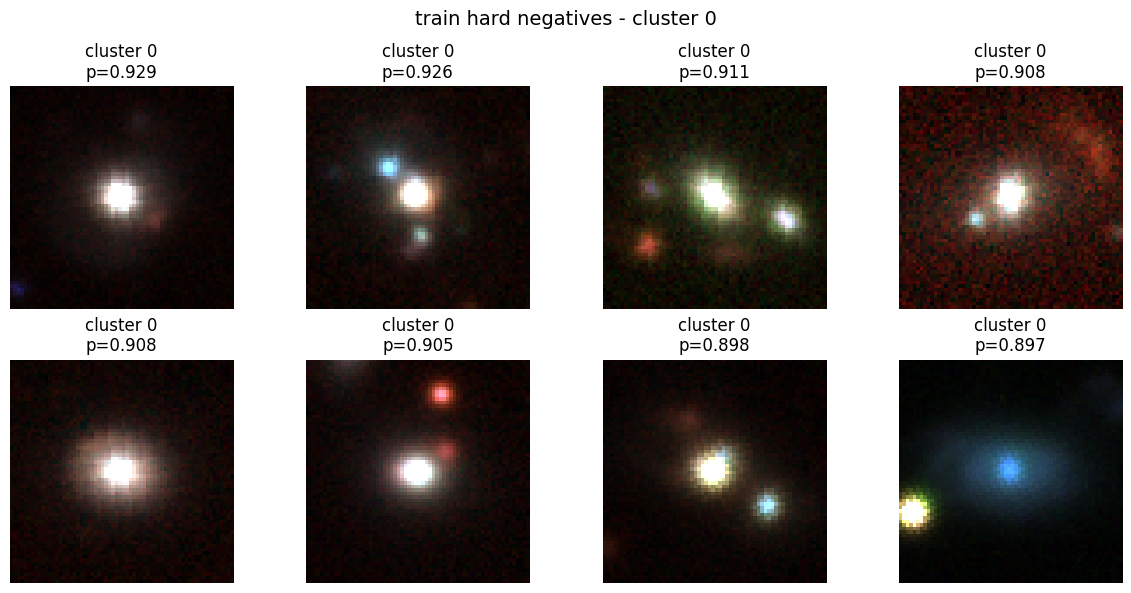

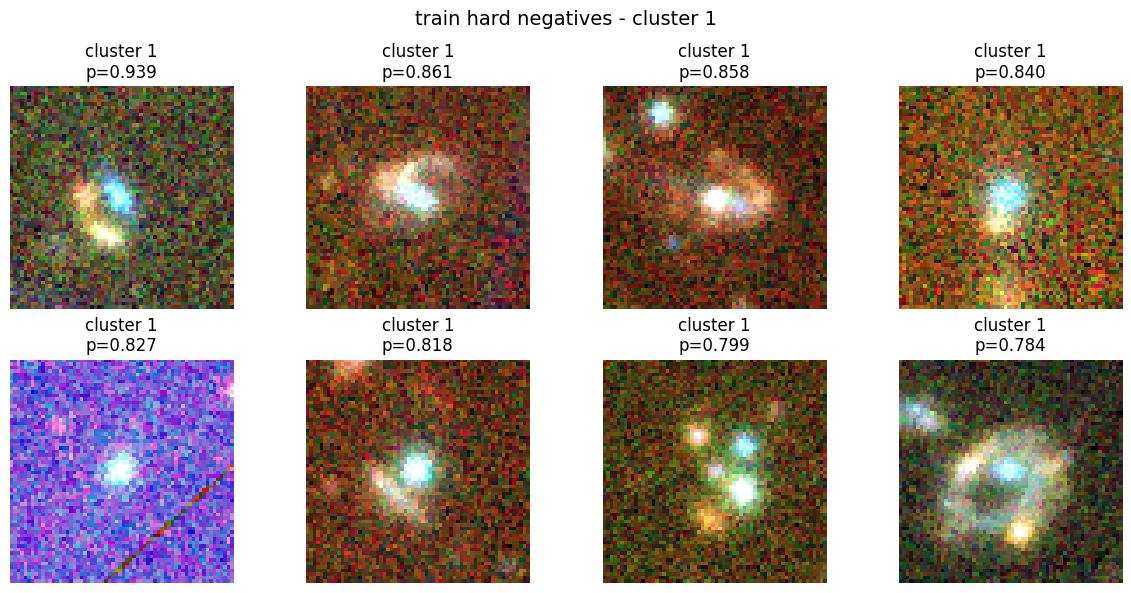

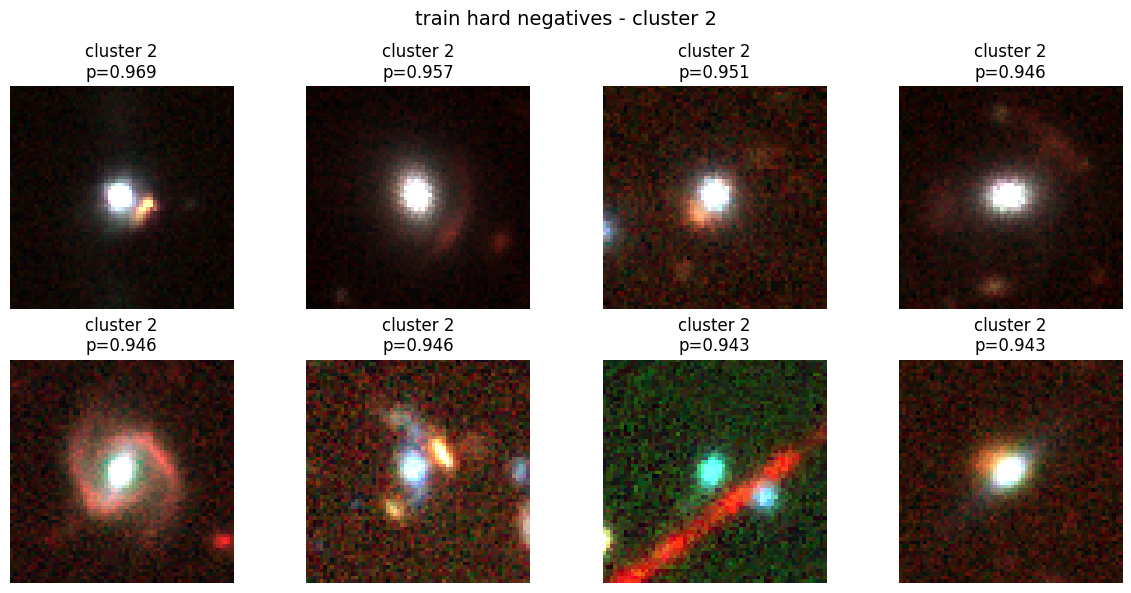

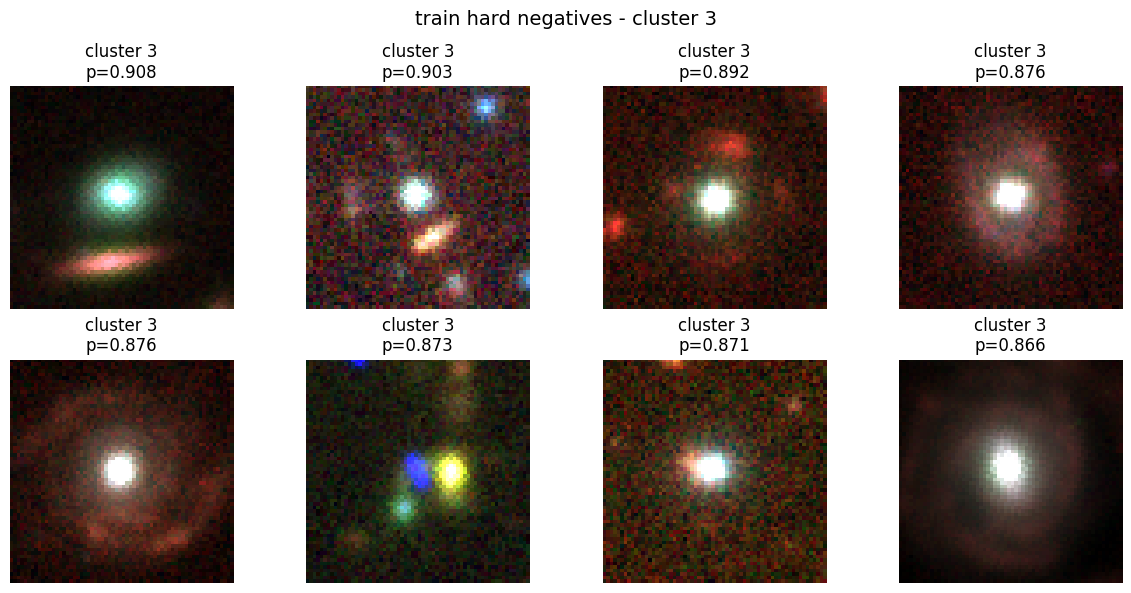

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


CaLiCo epoch 01 | train_loss=0.0554 train_auc=0.9896 | valid_auc=0.9934 | lr=1.47e-04 | 258.4s
CaLiCo epoch 02 | train_loss=0.0430 train_auc=0.9916 | valid_auc=0.9935 | lr=1.40e-04 | 258.5s
CaLiCo epoch 03 | train_loss=0.0348 train_auc=0.9928 | valid_auc=0.9935 | lr=1.28e-04 | 258.7s
CaLiCo epoch 04 | train_loss=0.0327 train_auc=0.9922 | valid_auc=0.9931 | lr=1.12e-04 | 258.3s
CaLiCo epoch 05 | train_loss=0.0312 train_auc=0.9920 | valid_auc=0.9931 | lr=9.44e-05 | 258.7s
CaLiCo epoch 06 | train_loss=0.0319 train_auc=0.9918 | valid_auc=0.9935 | lr=7.50e-05 | 258.1s
CaLiCo epoch 07 | train_loss=0.0313 train_auc=0.9927 | valid_auc=0.9932 | lr=5.56e-05 | 257.9s
CaLiCo epoch 08 | train_loss=0.0320 train_auc=0.9924 | valid_auc=0.9933 | lr=3.75e-05 | 258.2s
CaLiCo epoch 09 | train_loss=0.0304 train_auc=0.9926 | valid_auc=0.9935 | lr=2.20e-05 | 258.0s
Early stopping at epoch 9. Best epoch 3 with valid AUC=0.9935


,epoch,train_loss,train_auc,valid_auc,lr
0,1,0.055353,0.989595,0.993381,0.000147
1,2,0.043008,0.991639,0.993468,0.000140
2,3,0.034849,0.992821,0.993538,0.000128
3,4,0.032706,0.992204,0.993103,0.000112
4,5,0.031245,0.992041,0.993123,0.000094
5,6,0.031888,0.991846,0.993510,0.000075
6,7,0.031271,0.992705,0.993192,0.000056
7,8,0.031986,0.992423,0.993317,0.000038
8,9,0.030360,0.992591,0.993518,0.000022


Stage-A val AUC : 0.9932784321313115
CaLiCo  val AUC : 0.9935384268104901
Stage-A test AUC: 0.9899929488826944
CaLiCo  test AUC: 0.9898484998253696


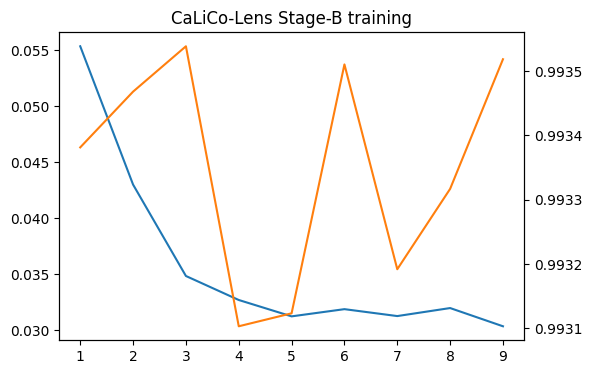

In [28]:

# =========================
# Prepare Stage-A features and pseudo contaminant labels
# =========================
seed_everything(CALICO_CFG.BASE_SEED)

stage_a_model = load_stage_a_model(seed=CALICO_CFG.BASE_SEED)

train_meta_df, train_fused, train_radial = collect_stage_a_outputs(stage_a_model, trn_df)
val_meta_df, val_fused, val_radial = collect_stage_a_outputs(stage_a_model, val_df)
test_meta_df, test_fused, test_radial = collect_stage_a_outputs(stage_a_model, test_df)

print("Stage-A single-seed val AUC:", roc_auc_score(val_meta_df["label"], val_meta_df["stage_a_prob"]))
print("Stage-A single-seed test AUC:", roc_auc_score(test_meta_df["label"], test_meta_df["stage_a_prob"]))

mined = mine_hard_negative_clusters(
    train_meta_df,
    train_fused,
    top_frac=CALICO_CFG.HARDNEG_TOP_FRAC,
    min_count=CALICO_CFG.HARDNEG_MIN_COUNT,
    n_clusters=CALICO_CFG.CONTAM_K,
)

if mined is None:
    train_contam = np.full(len(trn_df), -1, dtype=np.int64)
    val_contam = np.full(len(val_df), -1, dtype=np.int64)
    test_contam = np.full(len(test_df), -1, dtype=np.int64)
    n_contam_classes = 1
    print("Contaminant head disabled (insufficient mined negatives).")
else:
    train_contam = mined["contam_labels"]
    score_floor = float(np.quantile(train_meta_df.loc[train_meta_df.label == 0, "stage_a_prob"], 1.0 - CALICO_CFG.HARDNEG_TOP_FRAC))
    val_contam = assign_clusters_by_nearest(val_meta_df, val_fused, mined["kmeans"], score_floor=score_floor)
    test_contam = assign_clusters_by_nearest(test_meta_df, test_fused, mined["kmeans"], score_floor=score_floor)
    n_contam_classes = mined["kmeans"].n_clusters
    display(mined["hard_df"].head())
    plot_contaminant_cluster_gallery(mined["hard_df"], mined["hard_df"]["contam_cluster"].values, n_per_cluster=8)

np.save(CALICO_CFG.SAVE_DIR / "train_contam_labels.npy", train_contam)
np.save(CALICO_CFG.SAVE_DIR / "val_contam_labels.npy", val_contam)
np.save(CALICO_CFG.SAVE_DIR / "test_contam_labels.npy", test_contam)


# =========================
# Stage-B loaders
# =========================
def make_calico_loaders(seed):
    train_labels = trn_df["label"].values
    class_counts = np.bincount(train_labels.astype(int))
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels.astype(int)]

    # Slightly boost mined hard negatives instead of plain HNM retraining
    boost_mask = (train_contam >= 0)
    sample_weights = sample_weights.astype(np.float64)
    sample_weights[boost_mask] *= 1.5

    sampler_gen = torch.Generator()
    sampler_gen.manual_seed(seed)

    train_sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
        generator=sampler_gen
    )

    train_ds = LensDatasetWithMeta(trn_df, augment=True, contam_labels=train_contam)
    valid_ds = LensDatasetWithMeta(val_df, augment=False, contam_labels=val_contam)
    test_ds  = LensDatasetWithMeta(test_df, augment=False, contam_labels=test_contam)

    loader_gen = torch.Generator()
    loader_gen.manual_seed(seed)

    train_loader = DataLoader(
        train_ds,
        batch_size=CALICO_CFG.BATCH_SIZE,
        sampler=train_sampler,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        drop_last=True,
        worker_init_fn=seed_worker,
        generator=loader_gen,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    valid_loader = DataLoader(
        valid_ds,
        batch_size=CALICO_CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    test_loader = DataLoader(
        test_ds,
        batch_size=CALICO_CFG.BATCH_SIZE * 2,
        shuffle=False,
        num_workers=CFG.NUM_WORKERS,
        pin_memory=True,
        worker_init_fn=seed_worker,
        persistent_workers=(CFG.NUM_WORKERS > 0),
    )
    return train_loader, valid_loader, test_loader


# =========================
# Train Stage-B verifier (single seed)
# =========================
calico_model = CaLiCoLens(stage_a_model, n_contam_classes=n_contam_classes, freeze_stage_a=CALICO_CFG.FREEZE_STAGE_A).to(device)
train_loader_b, valid_loader_b, test_loader_b = make_calico_loaders(CALICO_CFG.BASE_SEED)

optimizer_b = torch.optim.AdamW(
    [p for p in calico_model.parameters() if p.requires_grad],
    lr=CALICO_CFG.LR,
    weight_decay=CALICO_CFG.WEIGHT_DECAY,
)
scheduler_b = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_b, T_max=CALICO_CFG.EPOCHS)
scaler_b = torch.amp.GradScaler(device.type, enabled=(CALICO_CFG.AMP and device.type == "cuda"))
criterion_b = BinaryFocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)

best_val_auc_b = -np.inf
best_state_b = None
best_epoch_b = 0
history_b = []

for epoch in range(1, CALICO_CFG.EPOCHS + 1):
    calico_model.train()
    train_losses = []
    train_probs = []
    train_targets = []

    t0 = time.time()
    for x, y, c in train_loader_b:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        c = c.to(device, non_blocking=True)

        optimizer_b.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(CALICO_CFG.AMP and device.type == "cuda")):
            out = calico_model(x)
            loss, parts = batch_calico_loss(out, x, y, c, criterion_b, contam_enabled=(n_contam_classes > 1))

        scaler_b.scale(loss).backward()
        scaler_b.unscale_(optimizer_b)
        torch.nn.utils.clip_grad_norm_(calico_model.parameters(), CALICO_CFG.CLIP_GRAD_NORM)
        scaler_b.step(optimizer_b)
        scaler_b.update()

        train_losses.append(loss.item())
        train_probs.append(torch.sigmoid(out["logit"]).detach().cpu().numpy())
        train_targets.append(y.detach().cpu().numpy())

    scheduler_b.step()

    train_probs = np.concatenate(train_probs)
    train_targets = np.concatenate(train_targets)
    train_auc_b = roc_auc_score(train_targets, train_probs)

    val_targets_b, val_probs_b = predict_calico(calico_model, valid_loader_b, use_tta=CFG.USE_TTA)
    val_auc_b = roc_auc_score(val_targets_b, val_probs_b)

    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "train_auc": float(train_auc_b),
        "valid_auc": float(val_auc_b),
        "lr": optimizer_b.param_groups[0]["lr"],
    }
    history_b.append(row)

    if val_auc_b > best_val_auc_b:
        best_val_auc_b = val_auc_b
        best_epoch_b = epoch
        best_state_b = copy.deepcopy(calico_model.state_dict())
        torch.save(best_state_b, CALICO_CFG.SAVE_DIR / "best_calico_stageb_seed42.pt")

    dt = time.time() - t0
    print(
        f"CaLiCo epoch {epoch:02d} | "
        f"train_loss={row['train_loss']:.4f} train_auc={row['train_auc']:.4f} | "
        f"valid_auc={row['valid_auc']:.4f} | lr={row['lr']:.2e} | {dt:.1f}s"
    )

    if device.type == "cuda":
        torch.cuda.empty_cache()
    gc.collect()

    if epoch - best_epoch_b >= CALICO_CFG.PATIENCE:
        print(f"Early stopping at epoch {epoch}. Best epoch {best_epoch_b} with valid AUC={best_val_auc_b:.4f}")
        break

calico_model.load_state_dict(best_state_b)
calico_model.eval()

history_b = pd.DataFrame(history_b)
display(history_b)

val_targets_calico, val_probs_calico = predict_calico(calico_model, valid_loader_b, use_tta=CFG.USE_TTA)
test_targets_calico, test_probs_calico = predict_calico(calico_model, test_loader_b, use_tta=CFG.USE_TTA)

print("Stage-A val AUC :", roc_auc_score(val_meta_df['label'], val_meta_df['stage_a_prob']))
print("CaLiCo  val AUC :", roc_auc_score(val_targets_calico, val_probs_calico))
print("Stage-A test AUC:", roc_auc_score(test_meta_df['label'], test_meta_df['stage_a_prob']))
print("CaLiCo  test AUC:", roc_auc_score(test_targets_calico, test_probs_calico))

history_b.to_csv(CALICO_CFG.SAVE_DIR / "calico_history.csv", index=False)
np.save(CALICO_CFG.SAVE_DIR / "val_targets_calico.npy", val_targets_calico)
np.save(CALICO_CFG.SAVE_DIR / "val_probs_calico.npy", val_probs_calico)
np.save(CALICO_CFG.SAVE_DIR / "test_targets_calico.npy", test_targets_calico)
np.save(CALICO_CFG.SAVE_DIR / "test_probs_calico.npy", test_probs_calico)

plt.figure(figsize=(6, 4))
plt.plot(history_b["epoch"], history_b["train_loss"], label="train loss")
plt.twinx()
plt.plot(history_b["epoch"], history_b["valid_auc"], label="valid auc", color="tab:orange")
plt.title("CaLiCo-Lens Stage-B training")
plt.show()


,policy,threshold,accuracy,balanced_accuracy,precision,recall,specificity,fpr,f1,youden_j,tp,fp,tn,fn
0,val_max_f1,0.781238,0.980598,0.905523,0.835294,0.820809,0.990237,0.009763,0.827988,0.811046,142.0,28.0,2840.0,31.0
1,val_max_youden,0.385341,0.941138,0.966078,0.491429,0.994220,0.937936,0.062064,0.657744,0.932155,172.0,178.0,2690.0,1.0
2,val_precision_at_recall>=0.80,0.784300,0.980598,0.902807,0.839286,0.815029,0.990586,0.009414,0.826979,0.805615,141.0,27.0,2841.0,32.0
3,val_recall_at_fpr<=0.01,0.781238,0.980598,0.905523,0.835294,0.820809,0.990237,0.009763,0.827988,0.811046,142.0,28.0,2840.0,31.0


,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn,policy
2,0.784300,0.989848,0.775405,0.991298,0.921992,0.538961,0.851282,0.992701,0.660040,0.998501,0.673505,0.655857,0.029585,0.882051,0.507692,166.0,142.0,19313.0,29.0,val_precision_at_recall>=0.80
0,0.781238,0.989848,0.775405,0.991247,0.921966,0.537217,0.851282,0.992650,0.658730,0.998501,0.672390,0.654526,0.029585,0.882051,0.507692,166.0,143.0,19312.0,29.0,val_max_f1
3,0.781238,0.989848,0.775405,0.991247,0.921966,0.537217,0.851282,0.992650,0.658730,0.998501,0.672390,0.654526,0.029585,0.882051,0.507692,166.0,143.0,19312.0,29.0,val_recall_at_fpr<=0.01
1,0.385341,0.989848,0.775405,0.938524,0.953724,0.135873,0.969231,0.938216,0.238335,0.999671,0.350713,0.224842,0.029585,0.882051,0.507692,189.0,1202.0,18253.0,6.0,val_max_youden


,model,threshold,roc_auc,pr_auc,accuracy,balanced_accuracy,precision,recall_sensitivity,specificity,f1,npv,mcc,cohen_kappa,brier_score,tpr_at_fpr_1e-2,tpr_at_fpr_1e-3,tp,fp,tn,fn
0,Stage-A seed42,0.750,0.989993,0.769342,0.986361,0.944883,0.414118,0.902564,0.987201,0.567742,0.999012,0.606291,0.561780,0.033533,0.892308,0.502564,176.0,249.0,19206.0,19.0
1,CaLiCo-Lens,0.785,0.989848,0.775405,0.991349,0.922017,0.540717,0.851282,0.992753,0.661355,0.998501,0.674624,0.657194,0.029585,0.882051,0.507692,166.0,141.0,19314.0,29.0


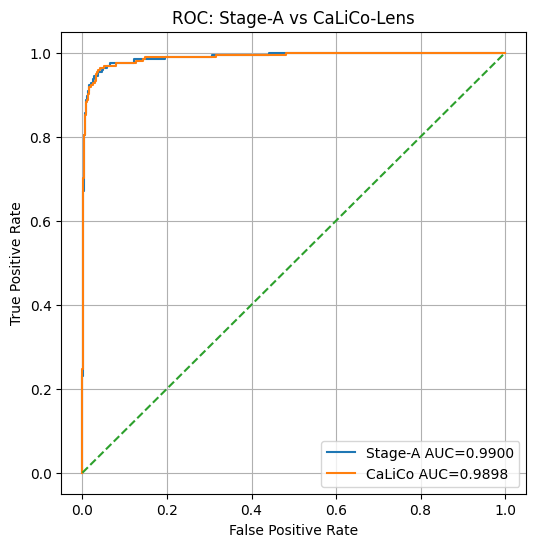

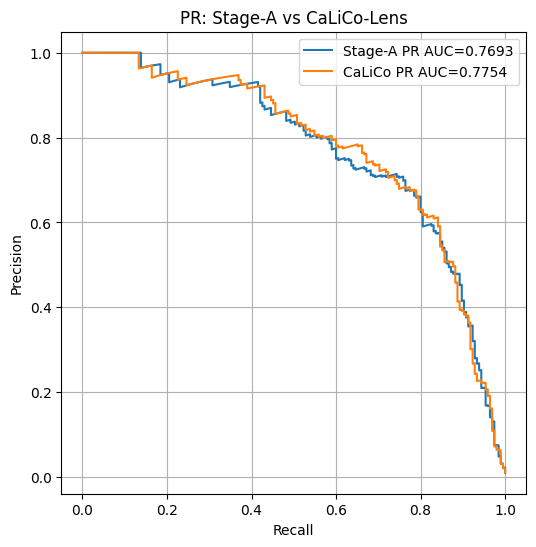

In [29]:

# =========================
# Thresholding analysis for CaLiCo-Lens
# =========================
def threshold_table_full(y_true, y_prob, thresholds=None):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    if thresholds is None:
        thresholds = np.unique(np.round(y_prob, 6))
        thresholds = np.concatenate([
            np.array([0.001, 0.005, 0.01]),
            thresholds,
            np.array([0.99, 0.995, 0.999])
        ])
        thresholds = np.unique(np.clip(thresholds, 0, 1))

    rows = []
    for thr in thresholds:
        pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
        recall = tp / (tp + fn + 1e-12)
        specificity = tn / (tn + fp + 1e-12)
        precision = tp / (tp + fp + 1e-12)
        fpr = fp / (fp + tn + 1e-12)
        acc = (tp + tn) / (tp + tn + fp + fn + 1e-12)
        bal_acc = 0.5 * (recall + specificity)
        f1 = 2 * precision * recall / (precision + recall + 1e-12)
        youden = recall + specificity - 1.0
        rows.append({
            "threshold": float(thr),
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "precision": precision,
            "recall": recall,
            "specificity": specificity,
            "fpr": fpr,
            "f1": f1,
            "youden_j": youden,
            "tp": int(tp), "fp": int(fp), "tn": int(tn), "fn": int(fn),
        })
    return pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)


def pick_threshold_policy(tbl, policy="max_f1", min_recall=0.80, max_fpr=0.01):
    if policy == "max_f1":
        row = tbl.sort_values(["f1", "precision", "recall"], ascending=[False, False, False]).iloc[0]
    elif policy == "max_youden":
        row = tbl.sort_values(["youden_j", "f1"], ascending=[False, False]).iloc[0]
    elif policy == "max_precision_at_recall":
        cand = tbl[tbl["recall"] >= min_recall].copy()
        if len(cand) == 0:
            raise ValueError(f"No threshold satisfies recall >= {min_recall}")
        row = cand.sort_values(["precision", "f1", "threshold"], ascending=[False, False, True]).iloc[0]
    elif policy == "max_recall_at_fpr":
        cand = tbl[tbl["fpr"] <= max_fpr].copy()
        if len(cand) == 0:
            raise ValueError(f"No threshold satisfies fpr <= {max_fpr}")
        row = cand.sort_values(["recall", "precision", "threshold"], ascending=[False, False, True]).iloc[0]
    else:
        raise ValueError("Unknown policy")
    return row

val_tbl_calico = threshold_table_full(val_targets_calico, val_probs_calico)
policies = {
    "val_max_f1": pick_threshold_policy(val_tbl_calico, "max_f1"),
    "val_max_youden": pick_threshold_policy(val_tbl_calico, "max_youden"),
    "val_precision_at_recall>=0.80": pick_threshold_policy(val_tbl_calico, "max_precision_at_recall", min_recall=0.80),
    "val_recall_at_fpr<=0.01": pick_threshold_policy(val_tbl_calico, "max_recall_at_fpr", max_fpr=0.01),
}
policy_df = pd.DataFrame(policies).T.reset_index().rename(columns={"index": "policy"})
display(policy_df)

policy_eval_rows = []
for _, row in policy_df.iterrows():
    thr = float(row["threshold"])
    summ, per_cls, _ = metric_summary(test_targets_calico, test_probs_calico, thr=thr)
    out = summ.iloc[0].to_dict()
    out["policy"] = row["policy"]
    policy_eval_rows.append(out)

policy_eval_df = pd.DataFrame(policy_eval_rows)
display(policy_eval_df.sort_values("f1", ascending=False))

# Baseline Stage-A threshold comparison using the same validation policy
base_best_thr, base_thr_table = choose_threshold(val_meta_df["label"].values, val_meta_df["stage_a_prob"].values, objective="f1")
base_test_summary, _, _ = metric_summary(test_meta_df["label"].values, test_meta_df["stage_a_prob"].values, thr=base_best_thr)
calico_best_thr, calico_thr_table = choose_threshold(val_targets_calico, val_probs_calico, objective="f1")
calico_test_summary, _, _ = metric_summary(test_targets_calico, test_probs_calico, thr=calico_best_thr)

compare_df = pd.concat([
    pd.DataFrame([{"model": "Stage-A seed42", **base_test_summary.iloc[0].to_dict()}]),
    pd.DataFrame([{"model": "CaLiCo-Lens", **calico_test_summary.iloc[0].to_dict()}]),
], ignore_index=True)
display(compare_df)

# ROC/PR plots
fpr_a, tpr_a, _ = roc_curve(test_meta_df["label"].values, test_meta_df["stage_a_prob"].values)
fpr_b, tpr_b, _ = roc_curve(test_targets_calico, test_probs_calico)
prec_a, rec_a, _ = precision_recall_curve(test_meta_df["label"].values, test_meta_df["stage_a_prob"].values)
prec_b, rec_b, _ = precision_recall_curve(test_targets_calico, test_probs_calico)

plt.figure(figsize=(6, 6))
plt.plot(fpr_a, tpr_a, label=f"Stage-A AUC={roc_auc_score(test_meta_df['label'], test_meta_df['stage_a_prob']):.4f}")
plt.plot(fpr_b, tpr_b, label=f"CaLiCo AUC={roc_auc_score(test_targets_calico, test_probs_calico):.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Stage-A vs CaLiCo-Lens")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
plt.plot(rec_a, prec_a, label=f"Stage-A PR AUC={average_precision_score(test_meta_df['label'], test_meta_df['stage_a_prob']):.4f}")
plt.plot(rec_b, prec_b, label=f"CaLiCo PR AUC={average_precision_score(test_targets_calico, test_probs_calico):.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("PR: Stage-A vs CaLiCo-Lens")
plt.legend()
plt.grid(True)
plt.show()


,path,label,split,folder,target,prob,pred,outcome
0,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.858856,1,TP
1,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.916561,1,TP
2,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.944532,1,TP
3,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.841995,1,TP
4,/kaggle/input/datasets/aryanaru69/dataset-task...,1,test,test_lenses,1,0.946618,1,TP


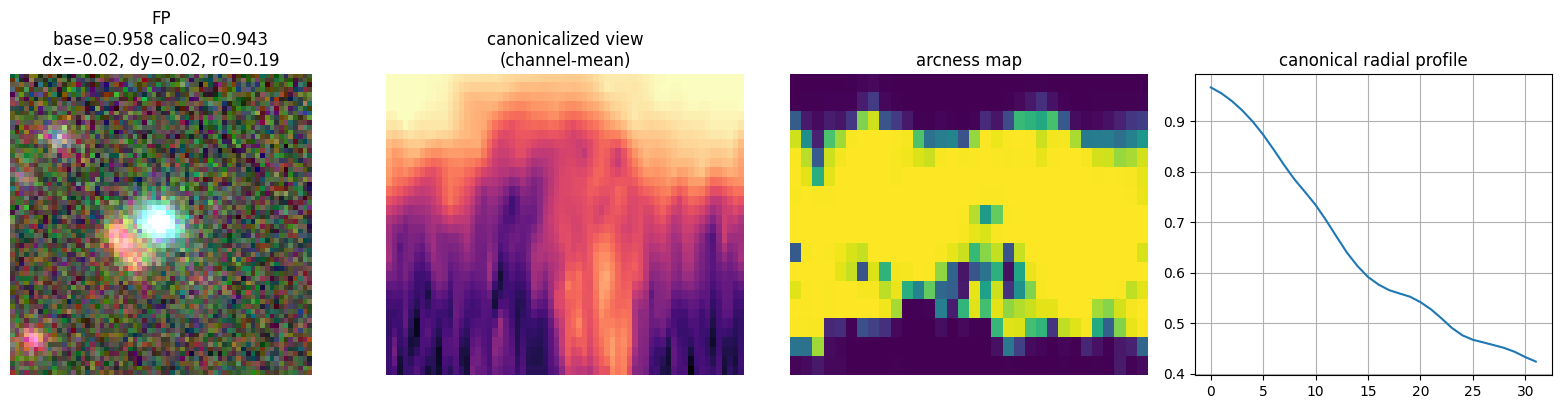

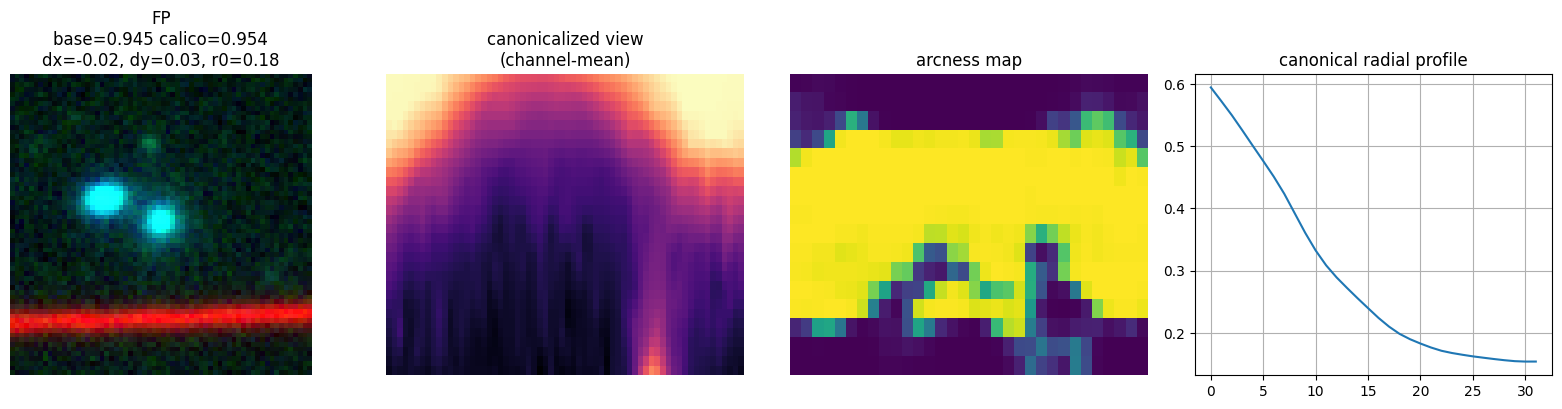

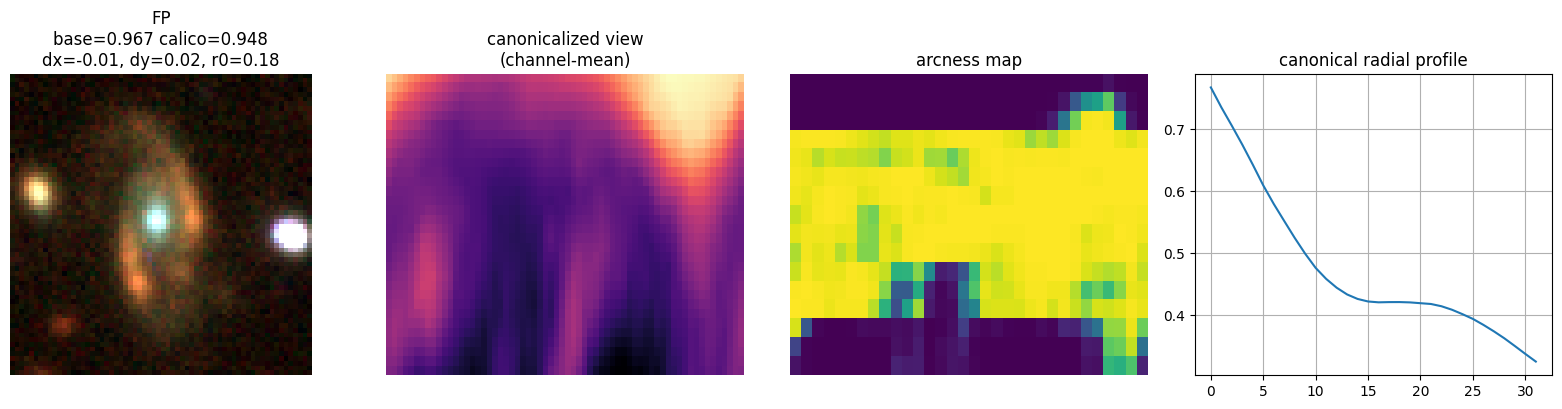

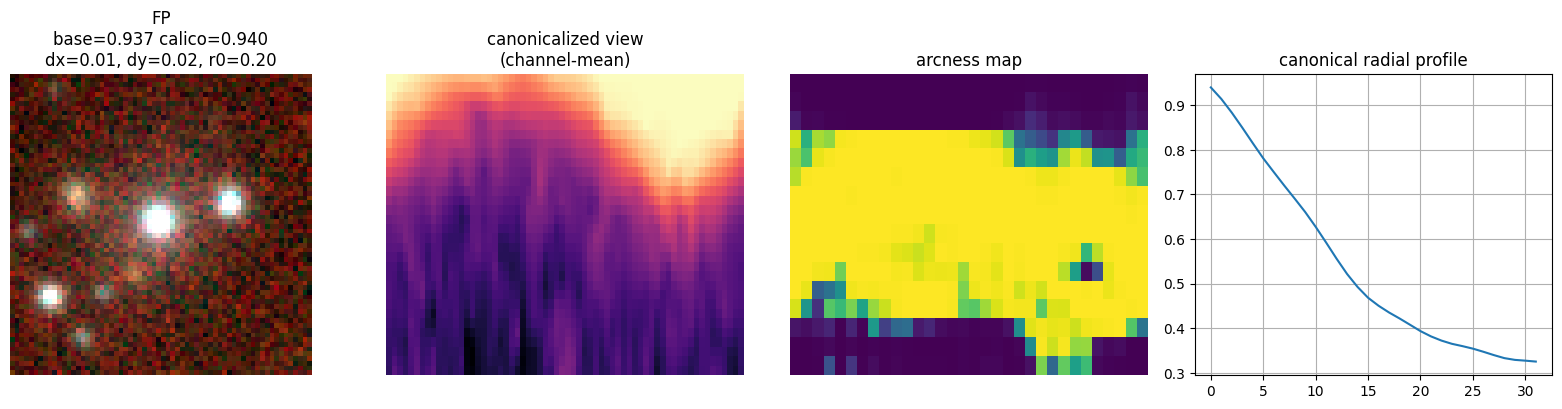

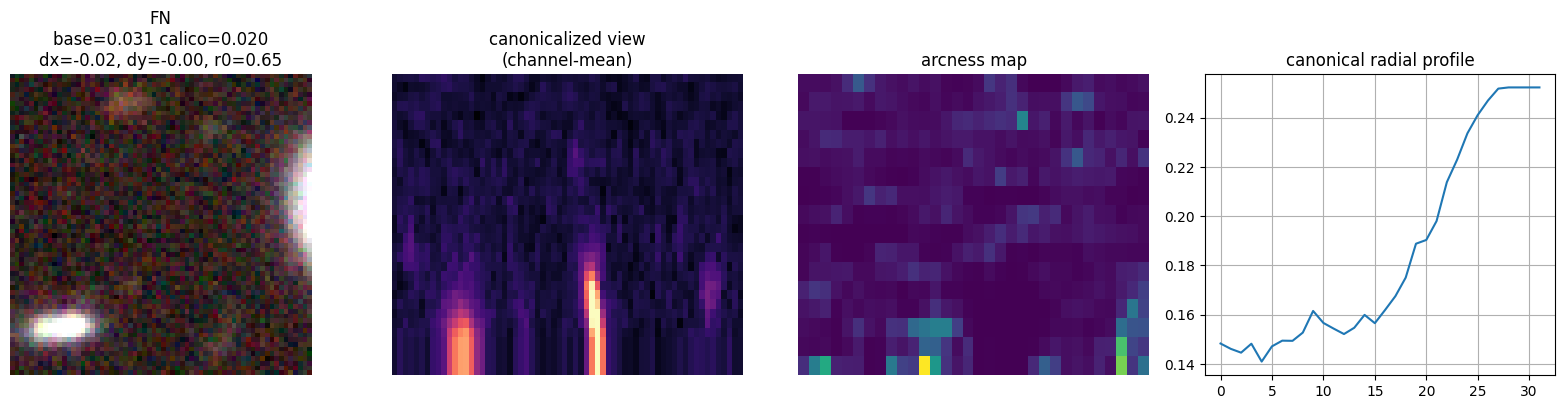

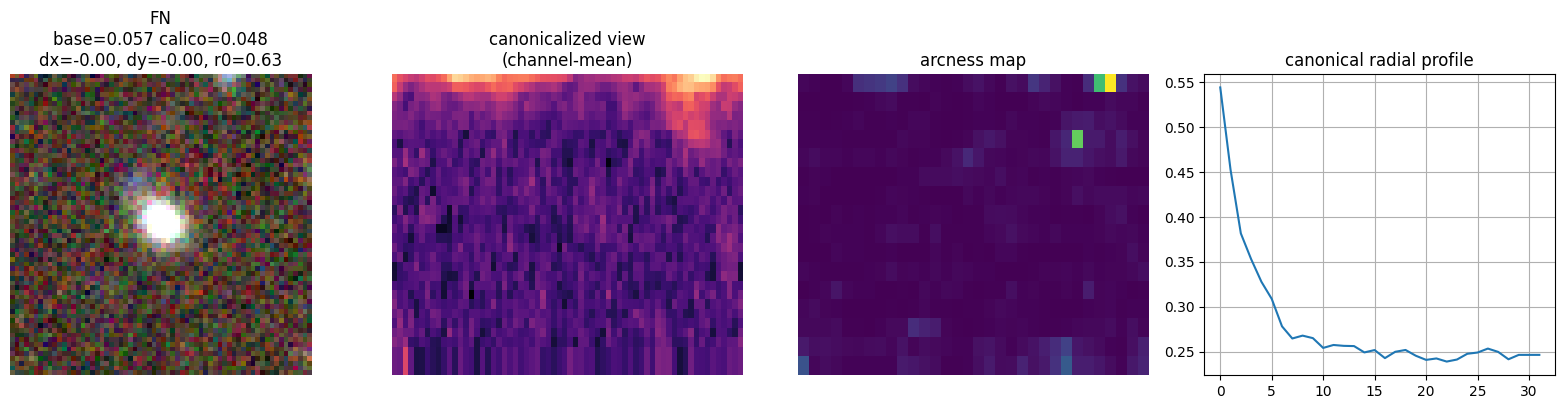

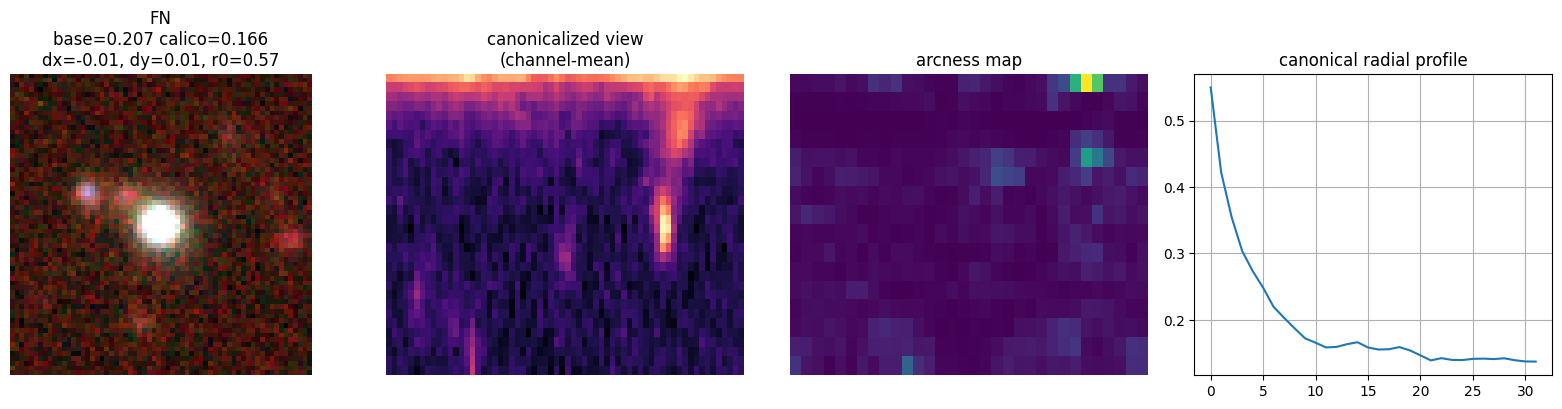

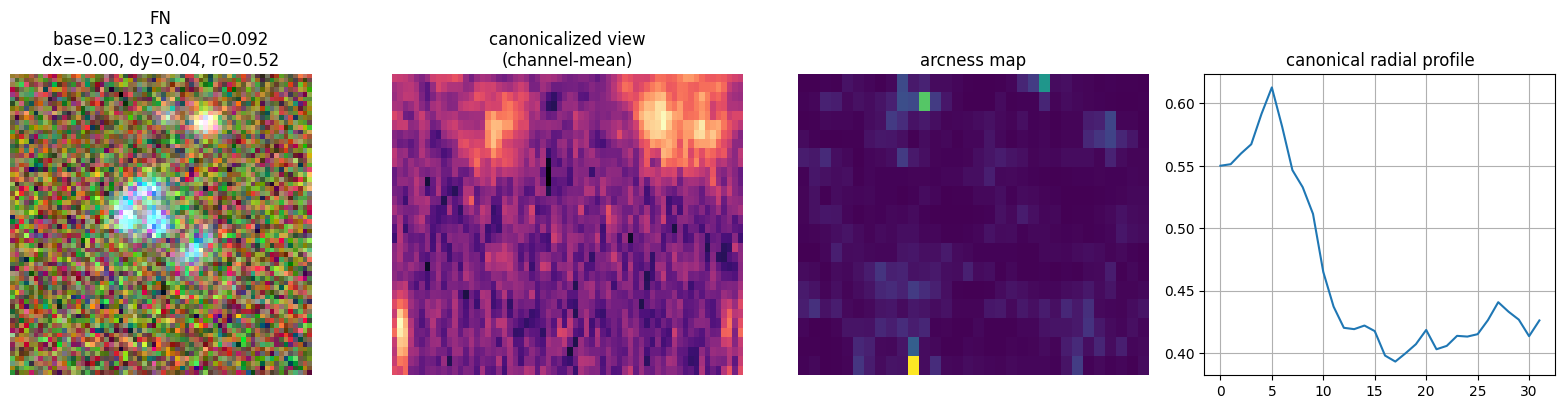

In [30]:

# =========================
# CaLiCo qualitative inspection
# =========================
def build_error_df(df, y_true, y_prob, thr):
    out = df.reset_index(drop=True).copy()
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= thr).astype(int)
    out["target"] = y_true
    out["prob"] = y_prob
    out["pred"] = y_pred
    names = []
    for t, p in zip(y_true, y_pred):
        if t == 1 and p == 1:
            names.append("TP")
        elif t == 0 and p == 1:
            names.append("FP")
        elif t == 1 and p == 0:
            names.append("FN")
        else:
            names.append("TN")
    out["outcome"] = names
    return out


@torch.inference_mode()
def inspect_calico_sample(model, path):
    x_np = astrophysical_stretch(load_npy(path))
    x = torch.tensor(x_np, dtype=torch.float32).unsqueeze(0).to(device)
    out = model(x)

    geom = {k: v[0].detach().cpu().item() for k, v in out["geom"].items()}
    prob = torch.sigmoid(out["logit"])[0].detach().cpu().item()
    base_prob = torch.sigmoid(out["base_logit"])[0].detach().cpu().item()
    canon = out["canon"][0].detach().cpu().numpy()
    arc = out["arc_prob"][0, 0].detach().cpu().numpy()

    return {
        "x": x_np,
        "canon": canon,
        "arc": arc,
        "geom": geom,
        "prob": prob,
        "base_prob": base_prob,
    }


def show_calico_gallery(error_df, outcome="FP", n=6, thr=None):
    sub = error_df[error_df["outcome"] == outcome].sort_values("prob", ascending=(outcome in ["FN", "TN"])).head(n)

    for _, row in sub.iterrows():
        info = inspect_calico_sample(calico_model, row.path)

        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        axes[0].imshow(np.stack([info["x"][0], info["x"][1], info["x"][2]], axis=-1))
        axes[0].set_title(
            f"{outcome}\nbase={info['base_prob']:.3f} calico={info['prob']:.3f}\n"
            f"dx={info['geom']['dx']:.2f}, dy={info['geom']['dy']:.2f}, r0={info['geom']['r0']:.2f}"
        )
        axes[0].axis("off")

        axes[1].imshow(info["canon"].mean(axis=0), cmap="magma", aspect="auto")
        axes[1].set_title("canonicalized view\n(channel-mean)")
        axes[1].axis("off")

        axes[2].imshow(info["arc"], cmap="viridis", aspect="auto")
        axes[2].set_title("arcness map")
        axes[2].axis("off")

        axes[3].plot(info["canon"].mean(axis=0).mean(axis=-1), label="canon radial mean")
        axes[3].set_title("canonical radial profile")
        axes[3].grid(True)
        plt.tight_layout()
        plt.show()


calico_error_df = build_error_df(test_df, test_targets_calico, test_probs_calico, thr=calico_best_thr)
display(calico_error_df.head())

show_calico_gallery(calico_error_df, outcome="FP", n=4)
show_calico_gallery(calico_error_df, outcome="FN", n=4)


## Mermaid: CaLiCo-Lens prototype

```mermaid
flowchart TD
    A[3-band 64x64 cutout] --> B[Stage-A DensePolarNet-Robust seed42]
    B --> B1[baseline lens score]
    B --> B2[fused morphology features]
    B2 --> C[Hard negative mining on train negatives]
    C --> D[Coarse contaminant clusters]

    B2 --> E[Geometry head: dx dy r0 q phi]
    A --> F[Elliptic-polar canonicalizer]
    E --> F
    F --> G[Canonical polar feature encoder]
    G --> H[Arcness map head]
    G --> I[Sector tokenizer]
    H --> I
    I --> J[Angular relation transformer]

    D --> K[Contaminant head]
    J --> L[Final verifier head]
    K --> L
    E --> L
    B1 --> L
    B2 --> L

    L --> M[Calico lens score]
    M --> N[ROC/PR + threshold analysis]
    M --> O[FP/FN canonicalized diagnostics]
```
